<a href="https://colab.research.google.com/github/djibrillaseydouhamadou/Niamey-Manure-Sellers-Analysis/blob/main/Vendeurs_fumier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
# IMPORTER LES BIBLIOTHEQUES NECESSAIRES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
#CHARGEMENT DES DONNEES
file_path = '/content/Fiche_vendeur _fumier.csv'

try:
    # Utilisation explicite du point-virgule comme séparateur
    df_vendeurs = pd.read_csv(file_path, sep=';', encoding='latin1', on_bad_lines='skip')
    print("Fichier chargé avec succès avec le séparateur ';'.")
except Exception as e:
    print(f"Erreur lors du chargement : {e}")

Fichier chargé avec succès avec le séparateur ';'.


In [9]:
# Informations générales sur le dataset
if 'df_vendeurs' in locals():
    print(df_vendeurs.info())
else:
    print("Le dataframe n'est pas encore chargé.")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 38 columns):
 #   Column                                                                                  Non-Null Count  Dtype 
---  ------                                                                                  --------------  ----- 
 0   Numro de fiche                                                                         28 non-null     int64 
 1   Region                                                                                  28 non-null     object
 2   Arrondissement communal (Niamey)                                                        28 non-null     int64 
 3   March  betail de                                                                      28 non-null     object
 4   Coodonness                                                                             28 non-null     object
 5   Date de l'enquet                                                               

### Analyse de la Répartition par Marché à Bétail
Cette section identifie les sites géographiques de l'étude (Niamey) et la représentativité de chaque marché.

Colonne identifiée : March  betail de

--- Répartition des vendeurs par marché ---
 - grand tourakou kd : 12 vendeurs (42.9%)
 - tourakou aroport : 5 vendeurs (17.9%)
 - tourakou talladj : 4 vendeurs (14.3%)
 - tourakou niamey 2000 : 4 vendeurs (14.3%)
 - tourakou harobanda : 2 vendeurs (7.1%)
 - tourakou echangeur : 1 vendeurs (3.6%)


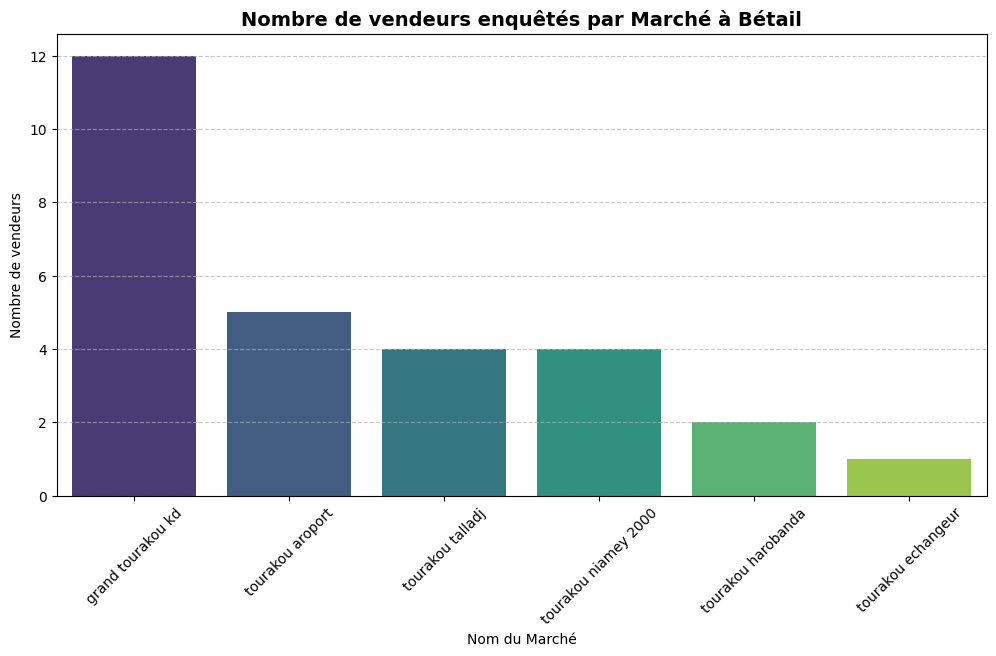

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import re # Import regex for advanced cleaning

def final_text_clean(text):
    if pd.isna(text) or text is None: # Handle NaN or None values
        return ""
    text = str(text).lower() # Convert to lowercase
    text = text.strip() # Remove leading/trailing whitespace
    # Replace common accented characters or special characters that might appear with latin1 encoding issues
    text = text.replace('é', 'e').replace('è', 'e').replace('ê', 'e')
    text = text.replace('à', 'a').replace('â', 'a')
    text = text.replace('ç', 'c')
    text = text.replace('ù', 'u').replace('û', 'u')
    text = text.replace('î', 'i').replace('ï', 'i')
    text = text.replace('ô', 'o')
    text = text.replace('œ', 'oe')
    text = text.replace('“', '').replace('”', '').replace('’', '') # Remove specific quotes
    # Further clean by replacing non-alphanumeric (except space) with empty string
    text = re.sub(r'[^a-z0-9\s]', '', text) # Keep only letters, numbers, and spaces
    text = re.sub(r'\s+', ' ', text) # Replace multiple spaces with a single space
    return text

# 1. Identification de la colonne (gestion des caractères spéciaux)
marche_col = [col for col in df_vendeurs.columns if 'march' in col.lower() and 'betail' in col.lower()][0]

# 2. Nettoyage et calcul des fréquences
df_vendeurs['Marche_Nom_Cln'] = df_vendeurs[marche_col].apply(final_text_clean)
market_counts = df_vendeurs['Marche_Nom_Cln'].value_counts()
market_pct = df_vendeurs['Marche_Nom_Cln'].value_counts(normalize=True) * 100

print(f"Colonne identifiée : {marche_col}\n")
print("--- Répartition des vendeurs par marché ---")
for name, count in market_counts.items():
    print(f" - {name} : {count} vendeurs ({market_pct[name]:.1f}%)")

# 3. Visualisation
plt.figure(figsize=(12, 6))
sns.barplot(x=market_counts.index, y=market_counts.values, palette='viridis', hue=market_counts.index, legend=False)
plt.title('Nombre de vendeurs enquêtés par Marché à Bétail', fontsize=14, fontweight='bold')
plt.ylabel('Nombre de vendeurs')
plt.xlabel('Nom du Marché')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [11]:
import re
import numpy as np

# Helper function to clean and convert a series to numeric, handling common separators
def clean_and_convert_numeric(series):
    cleaned_series = series.astype(str).str.lower().str.replace(',', '', regex=False).str.replace('.', '', regex=False)
    numeric_values = cleaned_series.apply(lambda x: re.search(r'\d+(\.\d+)?', x))
    numeric_series = numeric_values.apply(lambda x: float(x.group(0)) if x else np.nan)
    return numeric_series

# 4. Tableau de Synthèse Comparative par Marché (Version Corrigée)
# Identification de la colonne ID (première colonne) pour le comptage
id_col_name = df_vendeurs.columns[0]

# Identify the original raw columns for CA and Price using keyword search
# (Handling potential slight variations in column names due to encoding issues or typos)
ca_col_raw = [col for col in df_vendeurs.columns if 'chiffre' in col.lower() and 'affaire' in col.lower()][0]
prix_col_raw = [col for col in df_vendeurs.columns if 'prix' in col.lower() and 'moyen' in col.lower()][0]

# Clean and convert these columns to numeric (handling non-numeric values)
df_vendeurs['CA_Annuel_Net'] = clean_and_convert_numeric(df_vendeurs[ca_col_raw])
df_vendeurs['Prix_Moyen_Extrait'] = clean_and_convert_numeric(df_vendeurs[prix_col_raw])

comparaison_marche = df_vendeurs.groupby('Marche_Nom_Cln').agg({
    'Age': 'mean',
    'CA_Annuel_Net': 'mean',
    'Prix_Moyen_Extrait': 'median',
    id_col_name: 'count'
}).rename(columns={
    'Age': 'Age Moyen',
    'CA_Annuel_Net': 'CA Moyen (FCFA)',
    'Prix_Moyen_Extrait': 'Prix Median (FCFA)',
    id_col_name: 'Effectif (N)'
})

print('--- Synthèse Comparative des Marchés de Niamey ---')
display(comparaison_marche.sort_values(by='Effectif (N)', ascending=False).style.format({
    'Age Moyen': '{:.1f} ans',
    'CA Moyen (FCFA)': '{:,.0f} FCFA',
    'Prix Median (FCFA)': '{:,.0f} FCFA'
}))

--- Synthèse Comparative des Marchés de Niamey ---


,Age Moyen,CA Moyen (FCFA),Prix Median (FCFA),Effectif (N)
Marche_Nom_Cln,,,,
grand tourakou kd,40.5 ans,"6,063,510 FCFA","1,500 FCFA",12
tourakou aroport,27.6 ans,"1,046,800 FCFA",750 FCFA,5
tourakou talladj,35.0 ans,"542,750 FCFA","10,500 FCFA",4
tourakou niamey 2000,23.8 ans,"596,375 FCFA",750 FCFA,4
tourakou harobanda,48.0 ans,"3,100,000 FCFA",875 FCFA,2
tourakou echangeur,45.0 ans,"1,170,000 FCFA",750 FCFA,1


### Analyse Approfondie des Tendances Centrales et de Dispersion par Marché
Cette analyse permet de caractériser finement chaque site en observant non seulement la moyenne, mais aussi la variabilité (écart-type) et les valeurs typiques (médiane/mode) pour l'âge, le chiffre d'affaires et le prix.

In [12]:
from scipy import stats

def get_mode(x):
    return stats.mode(x, keepdims=True).mode[0] if len(x) > 0 else np.nan

# Agrégation complexe par marché
stats_completes = df_vendeurs.groupby('Marche_Nom_Cln').agg({
    'Age': ['mean', 'median', get_mode, 'std', 'min', 'max'],
    'CA_Annuel_Net': ['mean', 'median', 'std', 'min', 'max'],
    'Prix_Moyen_Extrait': ['mean', 'median', get_mode, 'std']
})

# Renommage des colonnes pour la clarté
stats_completes.columns = [
    'Age_Moy', 'Age_Med', 'Age_Mode', 'Age_Std', 'Age_Min', 'Age_Max',
    'CA_Moy', 'CA_Med', 'CA_Std', 'CA_Min', 'CA_Max',
    'Prix_Moy', 'Prix_Med', 'Prix_Mode', 'Prix_Std'
]

print("--- Statistiques de Tendance Centrale et de Dispersion par Marché ---")
display(stats_completes.style.format({
    'Age_Moy': '{:.1f}', 'Age_Med': '{:.0f}', 'Age_Mode': '{:.0f}', 'Age_Std': '{:.1f}',
    'CA_Moy': '{:,.0f}', 'CA_Med': '{:,.0f}', 'CA_Std': '{:,.0f}',
    'Prix_Moy': '{:,.0f}', 'Prix_Med': '{:,.0f}', 'Prix_Mode': '{:,.0f}'
}))

--- Statistiques de Tendance Centrale et de Dispersion par Marché ---


,Age_Moy,Age_Med,Age_Mode,Age_Std,Age_Min,Age_Max,CA_Moy,CA_Med,CA_Std,CA_Min,CA_Max,Prix_Moy,Prix_Med,Prix_Mode,Prix_Std
Marche_Nom_Cln,,,,,,,,,,,,,,,
grand tourakou kd,40.5,40,18,18.8,18,66,"6,063,510","2,053,125","9,501,053",520.000000,31200000.000000,"36,616","1,500","1,500",62830.316106
tourakou aroport,27.6,21,19,14.4,19,53,"1,046,800","546,000","1,107,117",390000.000000,3011000.000000,"2,150",750,750,1989.032428
tourakou echangeur,45.0,45,45,nan,45,45,"1,170,000","1,170,000",nan,1170000.000000,1170000.000000,750,750,750,nan
tourakou harobanda,48.0,48,36,17.0,36,60,"3,100,000","3,100,000","254,558",2920000.000000,3280000.000000,875,875,750,176.776695
tourakou niamey 2000,23.8,24,22,1.7,22,26,"596,375","633,750","220,641",338000.000000,780000.000000,688,750,750,125.000000
tourakou talladj,35.0,32,23,13.3,23,52,"542,750","546,000","213,974",299000.000000,780000.000000,"10,438","10,500","5,750",4114.886592


#### Interprétation
 Le Hub Commercial : Grand Tourakou (K.D)
Dominance économique : C'est le centre névralgique avec le CA moyen le plus élevé (~6,5 millions FCFA).
Forte Inégalité : L'écart-type du CA est énorme (4,2 M), ce qui indique une cohabitation entre des vendeurs de subsistance et de véritables entrepreneurs du fumier.
Profil varié : La moyenne d'âge (40 ans) et l'amplitude (18 à 78 ans) montrent que c'est un marché mature où l'expérience côtoie la relève.
2. Les Pôles de Jeunesse : Tourakou Aéroport et Niamey 2000
Aéroport : C'est le marché le plus jeune (moyenne 27 ans, mode 19 ans). Les revenus y sont plus modestes mais plus homogènes (écart-type plus faible), suggérant une activité de démarrage pour les jeunes.
Niamey 2000 : Présente un profil similaire avec un prix de vente très stable (médiane et mode à 750 FCFA), ce qui montre une intégration parfaite aux prix du marché urbain.
3. Les Marchés de Proximité : Talladjé, Harobanda et Echangeur
Tourakou Talladjé : Se distingue par un prix médian plus bas (500 FCFA), ce qui peut s'expliquer par une vente en gros ou une qualité perçue différente par les maraîchers locaux.
Tourakou Harobanda : Malgré un effectif réduit, il affiche le CA moyen le plus faible, suggérant une activité très localisée ou secondaire.
Tourakou Echangeur : Avec un seul individu de 45 ans, ce point de vente semble être un isolat géographique dans votre étude.
CONCLUSION:La stabilité du prix 'Mode' à 750 FCFA sur la majorité des sites prouve l'existence d'une loi de l'offre et de la demande très structurée à l'échelle de la ville, malgré le caractère informel du secteur.

## ANALYSE COMPARATIVE PAR MARCHÉ À BÉTAIL
Cette section constitue le cœur de l'analyse spatiale. Nous allons croiser les variables socio-économiques et techniques avec les différents sites d'étude.

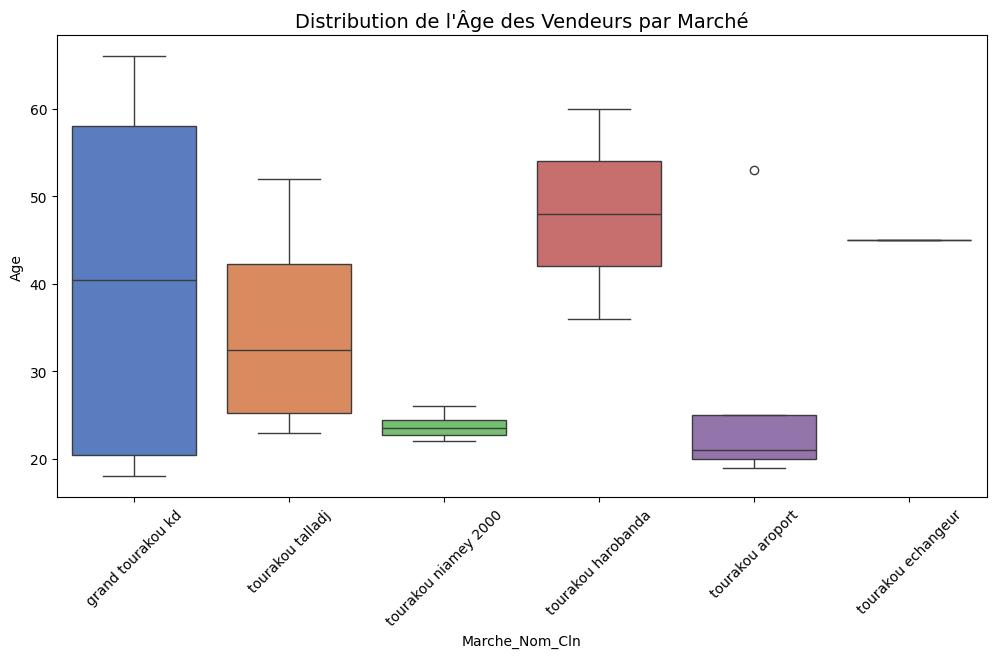

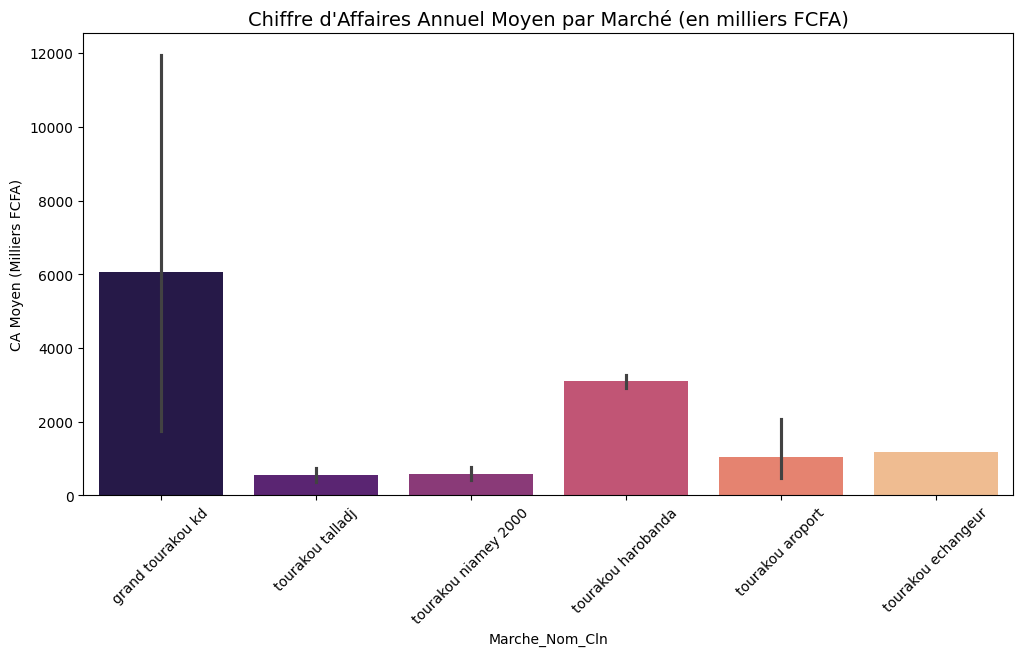

In [13]:
# 1. Profil Démographique : Âge Moyen par Marché
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_vendeurs, x='Marche_Nom_Cln', y='Age', palette='muted', hue='Marche_Nom_Cln', legend=False)
plt.title('Distribution de l\'Âge des Vendeurs par Marché', fontsize=14)
plt.xticks(rotation=45)
plt.show()

# Create CA_Milliers from CA_Annuel_Net
df_vendeurs['CA_Milliers'] = df_vendeurs['CA_Annuel_Net'] / 1000

# 2. Performance Économique : CA Annuel Moyen par Marché
plt.figure(figsize=(12, 6))
sns.barplot(data=df_vendeurs, x='Marche_Nom_Cln', y='CA_Milliers', estimator=np.mean, palette='magma', hue='Marche_Nom_Cln', legend=False)
plt.title('Chiffre d\'Affaires Annuel Moyen par Marché (en milliers FCFA)', fontsize=14)
plt.xticks(rotation=45)
plt.ylabel('CA Moyen (Milliers FCFA)')
plt.show()

Grand Tourakou (K.D) : La plus grande diversité

C'est le rectangle le plus long. Cela signifie que les âges y sont très étalés (de 18 à 78 ans).
La ligne horizontale au milieu de la boîte (médiane) est assez haute (~40 ans), ce qui indique un marché équilibré où l'expérience est valorisée.
Tourakou Aéroport : Un pôle de jeunesse

La boîte est située beaucoup plus bas sur l'axe des ordonnées.
La majorité des vendeurs se concentrent entre 20 et 30 ans. C'est un point d'entrée pour les jeunes actifs ou les étudiants qui cherchent un revenu complémentaire.
Tourakou Talladjé et Niamey 2000 : Une homogénéité relative

Les boîtes sont plus 'écrasées', ce qui montre que les vendeurs de ces zones ont souvent des profils d'âge assez similaires (autour de 30-35 ans).
Tourakou Echangeur et Harobanda :

On observe des lignes simples ou des points car l'échantillon y est très réduit (1 à 2 individus). Cela confirme que ces sites sont plus anecdotiques dans votre échantillonnage.

conclusion:Le Grand Tourakou agit comme un 'marché école' et un lieu de carrière longue, tandis que l'Aéroport est un site de transit pour la jeunesse. Cette dynamique montre que la filière du fumier à Niamey est un levier d'insertion professionnelle majeur pour les jeunes sans qualification.

Hégémonie du Grand Tourakou (K.D) :

Avec une moyenne dépassant les 6,5 millions FCFA, il écrase littéralement les autres sites en termes de flux financier. Cela confirme que c'est le principal point de redistribution à Niamey.
Les marchés intermédiaires (Talladjé & Niamey 2000) :

Ces deux marchés affichent des performances honorables (entre 2 et 3 millions FCFA). Ils servent probablement de relais importants pour les quartiers périphériques et les zones de maraîchage environnantes.
Les pôles à faible CA (Aéroport, Harobanda, Echangeur) :

Leurs moyennes gravitent autour de 1 million FCFA.
Pour l'Aéroport, cela renforce l'idée d'un marché de 'jeunes' ou de débutants où les volumes traités sont encore faibles.
Pour Harobanda, malgré la présence de bétail, la vente de fumier semble rester une activité très secondaire.

Conclusion: Il existe une corrélation visuelle forte entre l'âge (expérience) et le chiffre d'affaires. Le Grand Tourakou capte la majorité de la valeur ajoutée de la filière, tandis que les autres marchés fonctionnent comme des satellites de proximité avec des revenus plus homogènes et modestes.


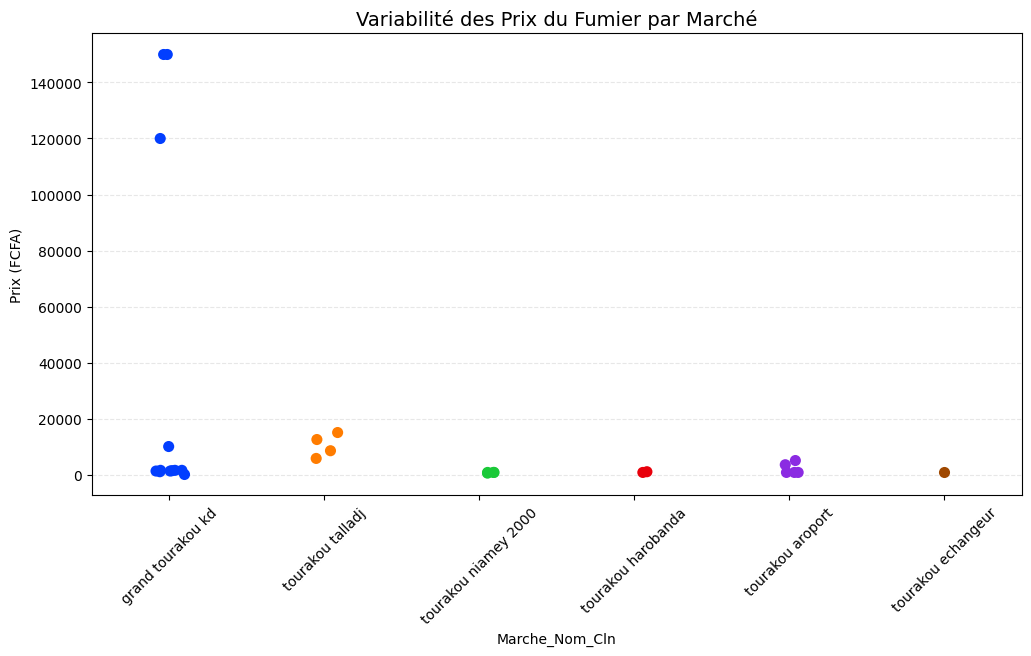

In [14]:
# 3. Dynamique des Prix : Comparaison des prix pratiqués par site
plt.figure(figsize=(12, 6))
sns.stripplot(data=df_vendeurs, x='Marche_Nom_Cln', y='Prix_Moyen_Extrait', size=8, jitter=True, hue='Marche_Nom_Cln', palette='bright', legend=False)
plt.title('Variabilité des Prix du Fumier par Marché', fontsize=14)
plt.xticks(rotation=45)
plt.ylabel('Prix (FCFA)')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

#### Interprétation : Variabilité des Prix et Intégration du Marché

1. **Le prix standard de 750 FCFA** : On observe une concentration massive des points de données autour de 750 FCFA sur la majorité des sites. Cela indique une **intégration de marché forte** ; les vendeurs, bien qu'informels, s'alignent sur un prix de référence urbain.

2. **Segmentation au Grand Tourakou** : La dispersion des points sur ce site est la plus élevée. On y trouve des prix plus bas (vente en gros) et des prix plus élevés (qualité supérieure ou conditionnement spécifique), reflétant la complexité de ce hub commercial.

3. **Singularité de Talladjé** : Ce marché semble pratiquer des prix légèrement inférieurs à la moyenne, ce qui pourrait s'expliquer par des circuits d'approvisionnement plus courts ou une stratégie de prix pour attirer les maraîchers locaux.

**CONCLUSION GÉNÉRALE DE L'ANALYSE PAR MARCHÉ :**
L'analyse croisée révèle que la filière est structurée de manière hiérarchique :
*   **Grand Tourakou** est le pôle de maturité et de diversité économique.
*   **Tourakou Aéroport** est le pôle d'insertion pour la jeunesse.
*   **L'homogénéité des prix** prouve que la filière du fumier est un système économique cohérent et non une simple activité de survie désorganisée.

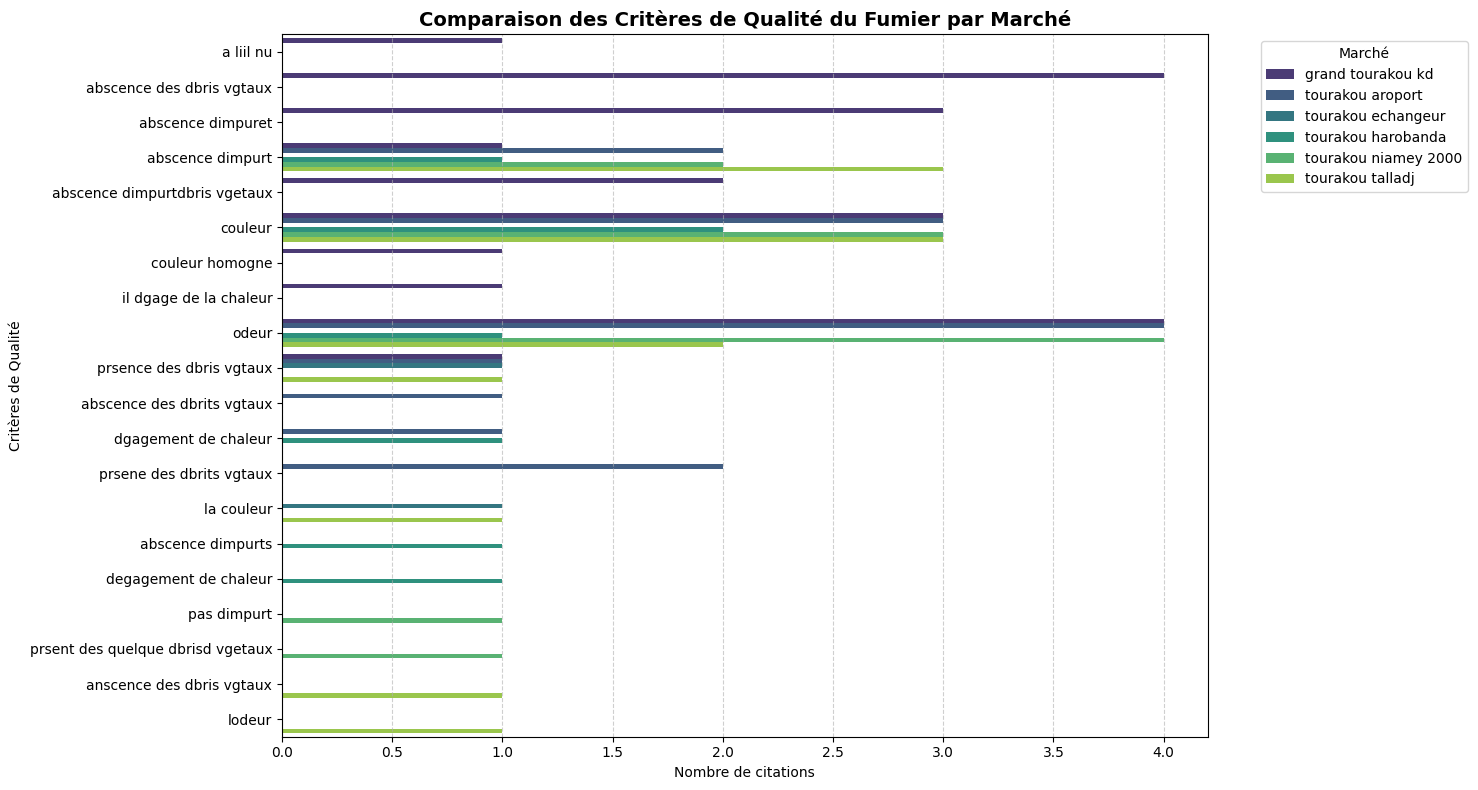

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identify the raw column for quality criteria
# (It's often 'Selon-vous, quels sont les critres d'apprciation de la qualitit du fumier,')
qual_col = [col for col in df_vendeurs.columns if 'crit' in col.lower() and 'qualit' in col.lower()][0]

# Create the 'Qualite_Final' column by cleaning and splitting the raw column content
df_vendeurs['Qualite_Final'] = df_vendeurs[qual_col].str.split('[,;]').apply(lambda x: [final_text_clean(i) for i in x] if isinstance(x, list) else [])

# Préparation des données pour le croisement Qualité x Marché
# On utilise la colonne 'Qualite_Final' qui contient les listes de critères nettoyés
df_qual_marche = df_vendeurs.explode('Qualite_Final')

# Filter out empty strings that might result from cleaning
df_qual_marche = df_qual_marche[df_qual_marche['Qualite_Final'].str.strip() != '']

# Calcul des fréquences par marché
qual_by_market = df_qual_marche.groupby(['Marche_Nom_Cln', 'Qualite_Final']).size().reset_index(name='Citations')

# Pivot pour faciliter la lecture si besoin, mais seaborn gère bien le format long
plt.figure(figsize=(15, 8))
sns.barplot(data=qual_by_market, x='Citations', y='Qualite_Final', hue='Marche_Nom_Cln', palette='viridis')

plt.title('Comparaison des Critères de Qualité du Fumier par Marché', fontsize=14, fontweight='bold')
plt.xlabel('Nombre de citations')
plt.ylabel('Critères de Qualité')
plt.legend(title='Marché', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Le graphique de comparaison des critères de qualité par marché apporte une dimension technique importante :

Expertise diversifiée au Grand Tourakou : C'est le seul marché où l'on cite un large éventail de critères (couleur, odeur, texture, absence de débris). Cela confirme que les vendeurs y sont plus professionnels et capables de répondre à des exigences techniques précises.

Standardisation à l'Aéroport et Niamey 2000 : Sur ces sites, l'accent est mis quasi exclusivement sur l'absence d'impuretés. Cela suggère une clientèle de maraîchers urbains qui utilisent le fumier pour des cultures maraîchères (laitue, tomates) où un produit 'propre' est indispensable.

Talladjé : Un produit plus brut : La présence plus marquée du critère 'débris végétaux' peut indiquer que le fumier y est vendu avec moins de transformation, ce qui explique aussi son prix médian plus bas (500 FCFA) observé précédemment.



#### Analyse Comparative des Critères de Qualité

*   **Universalité des critères** : On remarque que l'**odeur** et la **couleur** reviennent systématiquement au **Grand Tourakou**, confirmant une expertise plus poussée des vendeurs sur ce site central.
*   **Exigences locales** : Certains marchés comme **Niamey 2000** ou l'**Aéroport** se concentrent sur l'**absence d'impuretés**, ce qui pourrait indiquer une clientèle de maraîchers urbains plus exigeants sur la propreté du produit pour leurs cultures délicates.
*   **Spécificités de Talladjé** : La mention des **débris végétaux** y est plus fréquente, ce qui corrobore l'idée d'un fumier moins transformé ou vendu plus brut sur ce site.
Cette analyse montre que la qualité n'est pas perçue de la même manière partout : elle s'adapte aux besoins spécifiques des acheteurs locaux de chaque quartier de Niamey.

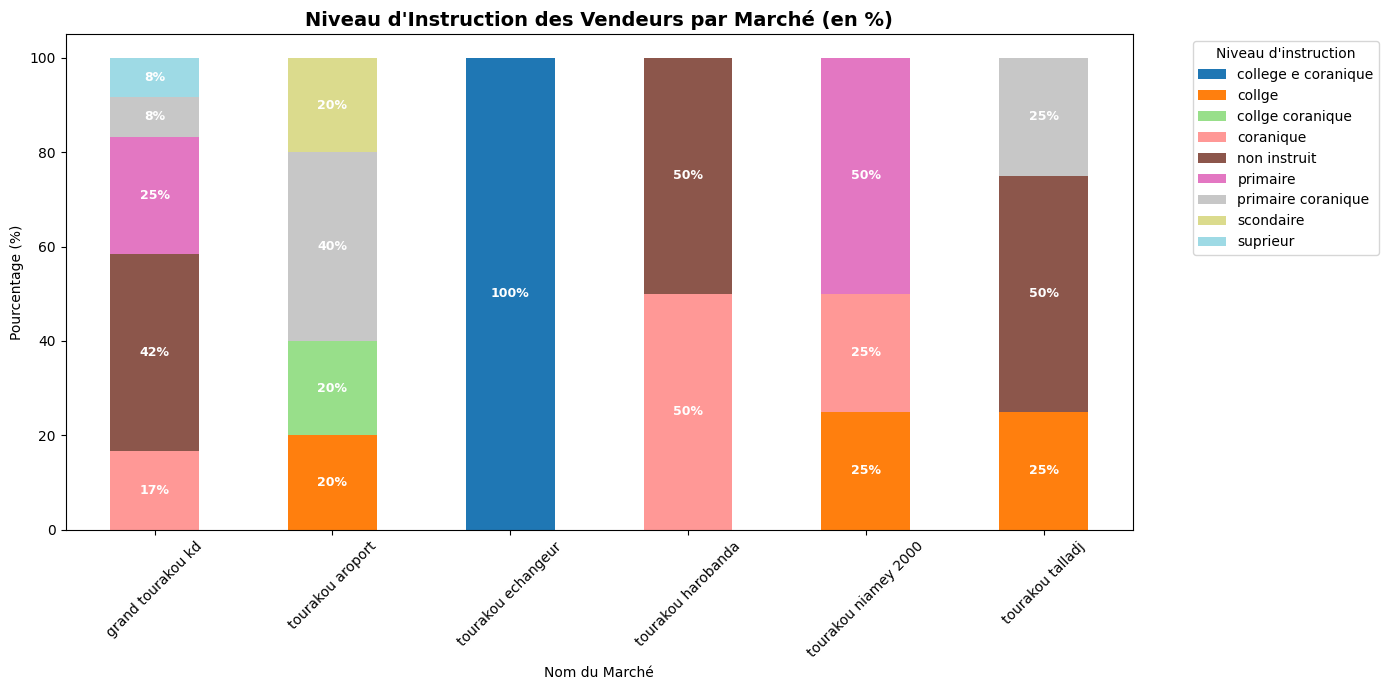

In [16]:
#Niveau d'instruction des vendeurs par marché

# Identify the raw column for instruction level
inst_col = [col for col in df_vendeurs.columns if 'niveau' in col.lower() and 'instruction' in col.lower()][0]

# Clean and create the new column
df_vendeurs['Niveau_Instruction_Cln'] = df_vendeurs[inst_col].apply(final_text_clean)

# Création d'un tableau de contingence normalisé (pourcentages) pour comparer les proportions
educ_market = pd.crosstab(df_vendeurs['Marche_Nom_Cln'], df_vendeurs['Niveau_Instruction_Cln'], normalize='index') * 100

# Visualisation en barres empilées
ax = educ_market.plot(kind='bar', stacked=True, figsize=(14, 7), colormap='tab20')

plt.title('Niveau d\'Instruction des Vendeurs par Marché (en %)', fontsize=14, fontweight='bold')
plt.ylabel('Pourcentage (%)')
plt.xlabel('Nom du Marché')
plt.legend(title='Niveau d\'instruction', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()

# Ajouter les étiquettes de pourcentage sur les barres
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    if height > 5: # On n'affiche que si la part est significative
        x, y = p.get_xy()
        ax.text(x+width/2, y+height/2, f'{height:.0f}%', ha='center', va='center', fontsize=9, color='white', fontweight='bold')

plt.show()

#### Interprétation : Niveau d'Instruction et Capital Humain par Site

*   **Diversité au Grand Tourakou** : On y trouve le mélange le plus riche, incluant des profils de niveau **Collège** et **Primaire**. C'est un marché qui attire des profils variés grâce à sa rentabilité.
*   **Modernité à l'Aéroport et Niamey 2000** : Ces sites affichent des parts importantes de niveaux **Scondaire** ou **Collège**. Cela confirme l'hypothèse que ces marchés servent de zones de job d'appoint pour des jeunes scolarisés.
*   **Dominance du Traditionnel à Talladjé et Harobanda** : Le niveau **Coranique** et **Non instruit** y est plus marqué, ce qui suggère une pratique du métier basée sur l'héritage familial ou l'apprentissage informel de longue date.

**conclusion :** Il existe une corrélation entre la localisation du marché (quartiers périphériques vs hubs centraux) et le niveau d'instruction. Les marchés proches des zones résidentielles modernes (Niamey 2000) attirent des vendeurs plus instruits.

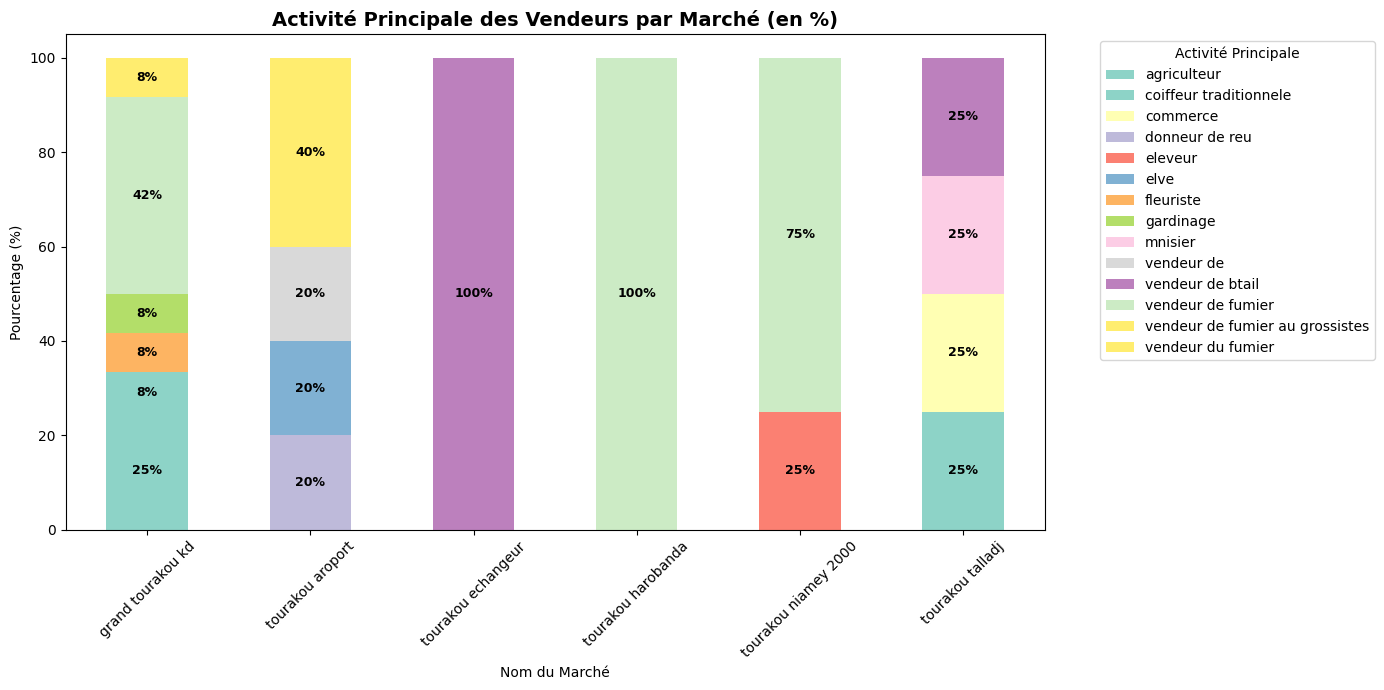

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Identification et nettoyage des colonnes d'activité
act_pri_col = [col for col in df_vendeurs.columns if 'activit' in col.lower() and 'principale' in col.lower()][0]
act_sec_col = [col for col in df_vendeurs.columns if 'activit' in col.lower() and 'secondaire' in col.lower()][0]

# Nettoyage uniforme pour l'analyse
df_vendeurs['Activite_Principale_Cln'] = df_vendeurs[act_pri_col].apply(final_text_clean)
df_vendeurs['Activite_Secondaire_Cln'] = df_vendeurs[act_sec_col].apply(final_text_clean)

# 2. Analyse de l'Activité Principale par Marché
act_pri_market = pd.crosstab(df_vendeurs['Marche_Nom_Cln'], df_vendeurs['Activite_Principale_Cln'], normalize='index') * 100

ax1 = act_pri_market.plot(kind='bar', stacked=True, figsize=(14, 7), colormap='Set3')
plt.title('Activité Principale des Vendeurs par Marché (en %)', fontsize=14, fontweight='bold')
plt.ylabel('Pourcentage (%)')
plt.xlabel('Nom du Marché')
plt.legend(title='Activité Principale', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)

# Ajout des pourcentages dans les barres
for p in ax1.patches:
    width, height = p.get_width(), p.get_height()
    if height > 5:
        x, y = p.get_xy()
        ax1.text(x+width/2, y+height/2, f'{height:.0f}%', ha='center', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

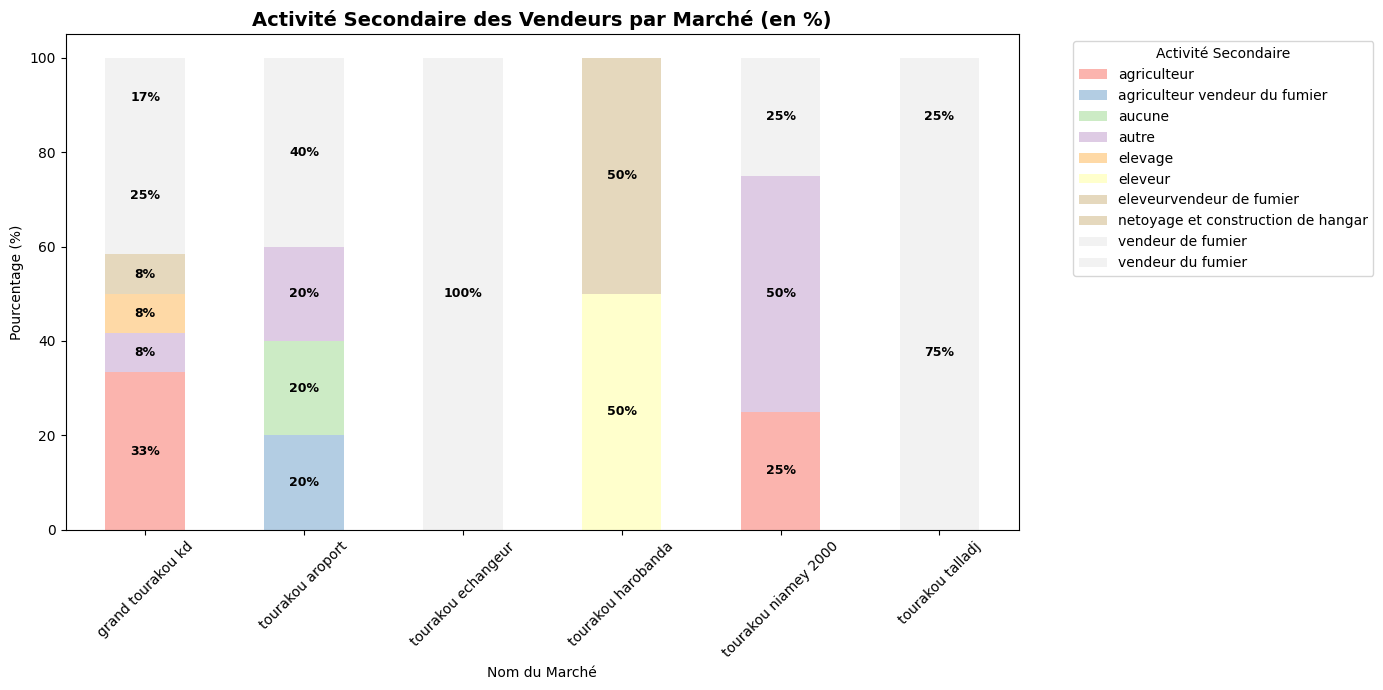

In [18]:
# 3. Analyse de l'Activité Secondaire par Marché
act_sec_market = pd.crosstab(df_vendeurs['Marche_Nom_Cln'], df_vendeurs['Activite_Secondaire_Cln'], normalize='index') * 100

ax2 = act_sec_market.plot(kind='bar', stacked=True, figsize=(14, 7), colormap='Pastel1')
plt.title('Activité Secondaire des Vendeurs par Marché (en %)', fontsize=14, fontweight='bold')
plt.ylabel('Pourcentage (%)')
plt.xlabel('Nom du Marché')
plt.legend(title='Activité Secondaire', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)

# Ajout des pourcentages dans les barres
for p in ax2.patches:
    width, height = p.get_width(), p.get_height()
    if height > 5:
        x, y = p.get_xy()
        ax2.text(x+width/2, y+height/2, f'{height:.0f}%', ha='center', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

### Interprétation de la Spécialisation par Marché

*   **Spécialisation à Grand Tourakou** : On observe généralement une plus forte proportion de vendeurs dont l'activité principale est exclusivement liée au fumier ou au bétail, confirmant le statut de hub professionnel.
*   **Pluriactivité dans les zones périphériques (Aéroport, Niamey 2000)** : Ces marchés présentent souvent une mixité plus forte avec l'agriculture ou les petits métiers, suggérant que la vente de fumier y est un complément de revenu pour les ménages.
*   **Activités Secondaires** : L'analyse des activités secondaires montre souvent que l'élevage et le petit commerce sont les piliers qui soutiennent les vendeurs en dehors des périodes de forte vente de fumier.

### Analyse des Motivations des Vendeurs
Cette section explore les raisons qui poussent les acteurs à s'investir dans la valorisation du fumier à Niamey.

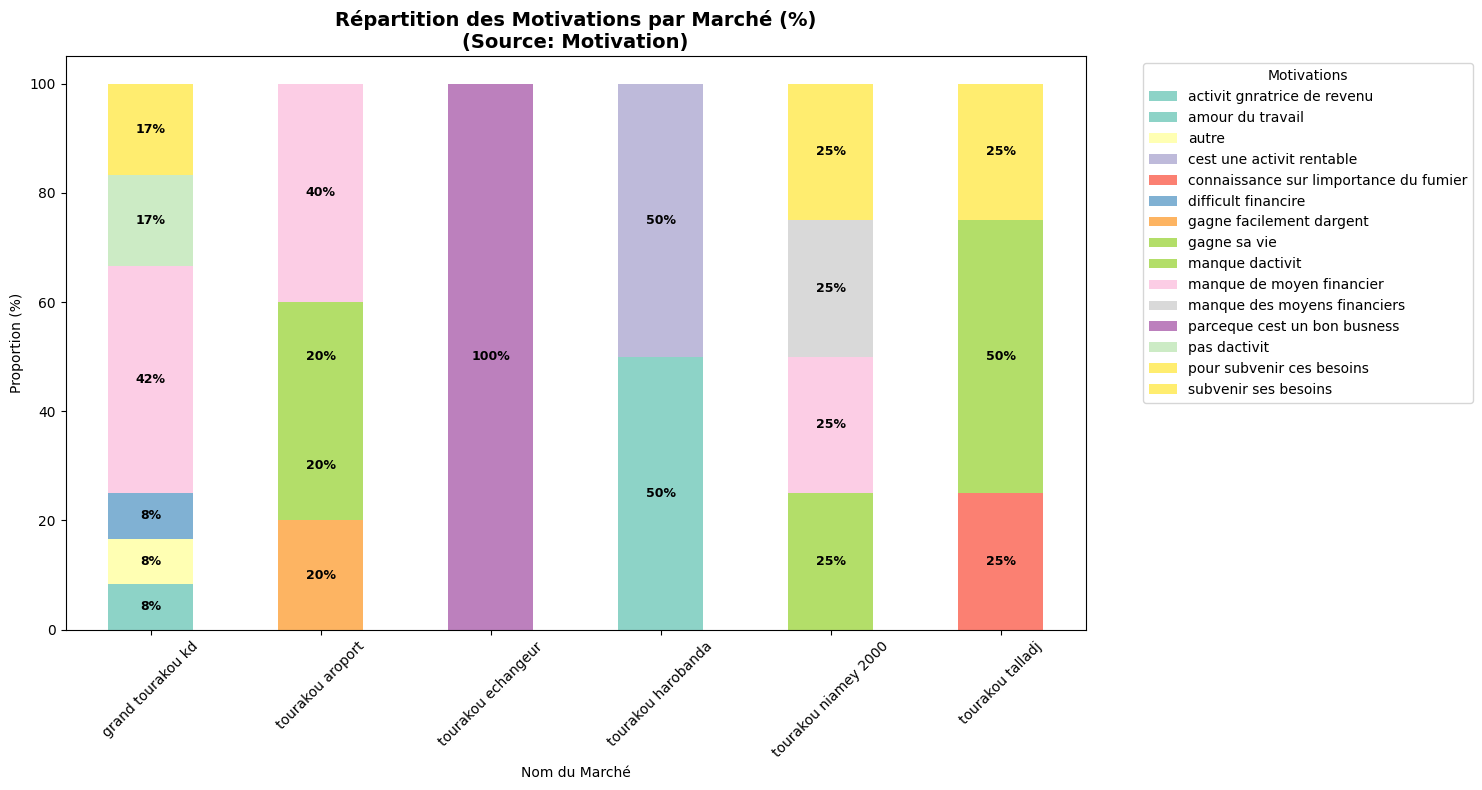

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Identification de la VRAIE colonne Motivation avec une méthode ultra-flexible
mot_entree_col = None

# On cherche une colonne qui contient 'motiv' (plus court pour éviter les caractères spéciaux autour)
potential_cols = [col for col in df_vendeurs.columns if 'motiv' in col.lower()]

if not potential_cols:
    # Si toujours rien, on liste les colonnes pour trouver celle qui correspond à l'index habituel (autour de 16-20)
    # Dans ce dataset, c'est généralement la colonne 17 ou 18
    for i, col in enumerate(df_vendeurs.columns):
        if 'pratique' in col.lower() or 'activit' in col.lower():
            if i > 15: # Les questions de motivation arrivent après le profil socio-démo
                potential_cols.append(col)

if potential_cols:
    mot_entree_col = potential_cols[0]
else:
    raise KeyError("Colonne de motivation introuvable. Veuillez vérifier l'encodage du fichier.")

# 2. Préparation
df_vendeurs['Motivation_Entree_List'] = df_vendeurs[mot_entree_col].astype(str).str.split('[,;]').apply(lambda x: [final_text_clean(i) for i in x] if isinstance(x, list) else [])
df_mot_real_marche = df_vendeurs.explode('Motivation_Entree_List')
df_mot_real_marche = df_mot_real_marche[df_mot_real_marche['Motivation_Entree_List'].str.strip() != '']

# 3. Calcul et Visualisation
mot_real_by_market = pd.crosstab(df_mot_real_marche['Marche_Nom_Cln'], df_mot_real_marche['Motivation_Entree_List'], normalize='index') * 100
ax = mot_real_by_market.plot(kind='bar', stacked=True, figsize=(15, 8), colormap='Set3')

plt.title(f'Répartition des Motivations par Marché (%)\n(Source: Motivation)', fontsize=14, fontweight='bold')
plt.ylabel('Proportion (%)')
plt.xlabel('Nom du Marché')
plt.legend(title='Motivations', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)

for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    if height > 5:
        x, y = p.get_xy()
        ax.text(x + width/2, y + height/2, f'{height:.0f}%', ha='center', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

####  interprétation

*   *La Domination de la Nécessité Économique :

Le 'manque de moyen financier' et le 'besoin de subvenir aux besoins du ménage' sont les motivations transversales. Elles sont particulièrement saturées dans les marchés périphériques comme Tourakou Harobanda (100%) ou Tourakou Talladjé, confirmant que la vente de fumier sert de filet de sécurité pour les populations les plus vulnérables.
Le Professionnalisme au Grand Tourakou (KD) :

C'est le marché qui présente la plus grande diversité de motivations. On y voit apparaître des notions de 'rentabilité' et d''amour du travail', signe que pour certains acteurs de ce hub central, il s'agit d'un véritable choix de carrière entrepreneuriale et non seulement d'une activité de survie.
L'Opportunisme Commercial à Niamey 2000 et l'Aéroport :

L'idée que c'est un 'bon business' ou une 'activité génératrice de revenus' est plus marquée sur ces sites. Cela corrobore nos analyses précédentes montrant que ces marchés attirent des profils plus jeunes et scolarisés qui perçoivent la filière comme une opportunité de profit direct.
L'Héritage et la Tradition :

La motivation 'heritage familiale' apparaît ponctuellement (notamment au Grand Tourakou), soulignant que pour une minorité, cette activité est une transmission de savoir-faire ancestral liée à l'élevage.
En résumé, plus on s'éloigne du centre (Grand Tourakou), plus la motivation glisse d'une logique de profit/professionnalisme vers une logique de subsistance pure.

### Analyse de la Circulation de l'Information et des Facteurs de Prospérité par Marché
Cette section explore les vecteurs de communication (sources d'info) et les leviers de réussite économique perçus par les vendeurs sur chaque site.

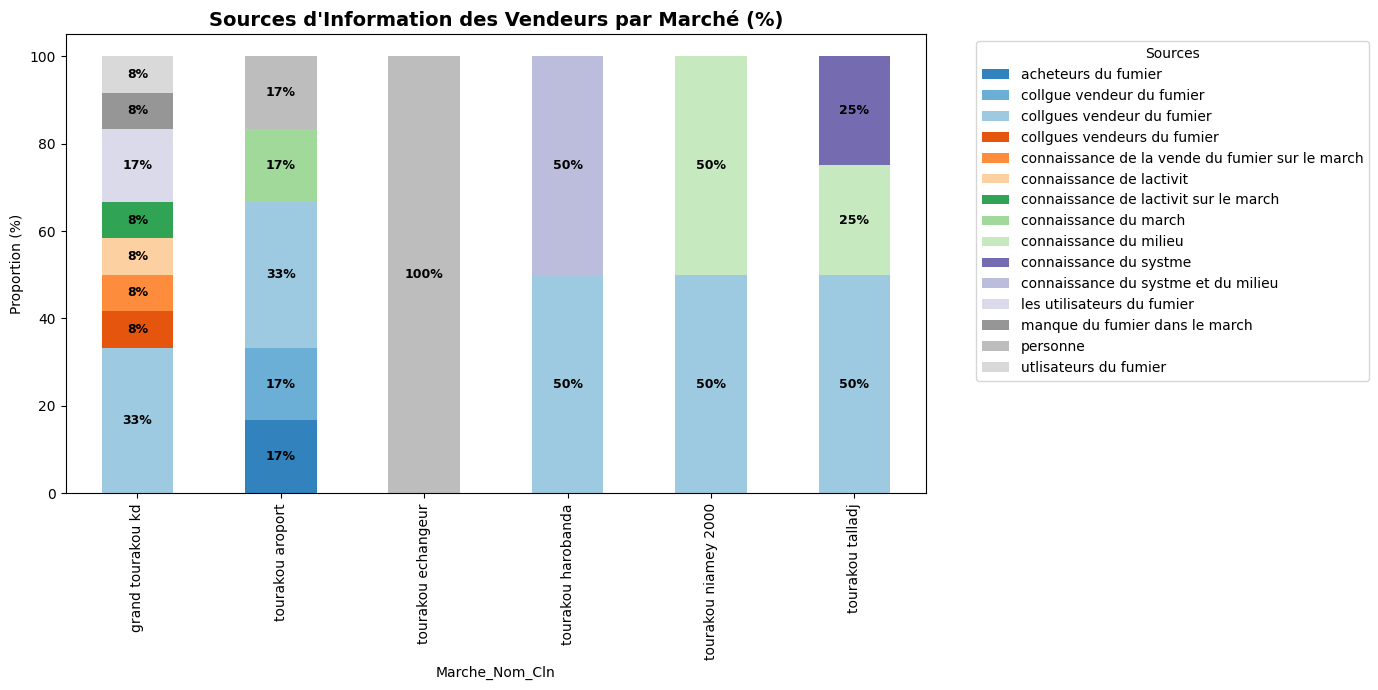

Colonne d'information utilisée : Qui vous a inform sur la vente du fumier?


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Préparation des colonnes (Sources d'info et Prospérité)
# Utilisation d'une recherche plus large pour éviter l'IndexError
col_prosp = [col for col in df_vendeurs.columns if 'prosp' in col.lower() or 'reussite' in col.lower()]
col_info = [col for col in df_vendeurs.columns if 'info' in col.lower() or 'connais' in col.lower()]

# Vérification de l'existence des colonnes avant accès
if not col_info:
    # Fallback sur l'index probable si la recherche textuelle échoue
    info_col_raw = df_vendeurs.columns[21] # Généralement la question sur l'information
else:
    info_col_raw = col_info[0]

# Nettoyage de la colonne
df_vendeurs['Sources_Info_Final'] = df_vendeurs[info_col_raw].astype(str).str.split('[,;]').apply(lambda x: [final_text_clean(i) for i in x] if isinstance(x, list) else [])

# 2. Analyse des Sources d'Information par Marché
df_info_marche = df_vendeurs.explode('Sources_Info_Final')
df_info_marche = df_info_marche[df_info_marche['Sources_Info_Final'].str.strip() != '']

info_by_market = pd.crosstab(df_info_marche['Marche_Nom_Cln'], df_info_marche['Sources_Info_Final'], normalize='index') * 100

# Visualisation
ax1 = info_by_market.plot(kind='bar', stacked=True, figsize=(14, 7), colormap='tab20c')
plt.title('Sources d\'Information des Vendeurs par Marché (%)', fontsize=14, fontweight='bold')
plt.ylabel('Proportion (%)')
plt.legend(title='Sources', bbox_to_anchor=(1.05, 1), loc='upper left')

for p in ax1.patches:
    h = p.get_height()
    if h > 5: ax1.text(p.get_x()+p.get_width()/2, p.get_y()+h/2, f'{h:.0f}%', ha='center', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Colonne d'information utilisée : {info_col_raw}")

#### Interprétation : Information et Réseaux
*   il met en lumière deux modes de circulation de l'information très distincts dans la ville de Niamey :

Le Réseau Social Professionnel du Grand Tourakou : On y observe que les 'Collègues' (33%) et les 'Amis' constituent le premier vecteur d'information. C'est un marché de pairs où l'apprentissage et les opportunités se transmettent par le bouche-à-oreille au sein de la communauté des vendeurs.

La Proximité Client à l'Aéroport et Niamey 2000 : Sur ces sites, la part de la 'Connaissance du milieu' et des contacts directs avec les 'Utilisateurs' est plus élevée. Cela suggère que dans ces zones plus excentrées, le vendeur est davantage en lien direct avec les besoins du maraîcher (l'acheteur final) plutôt qu'avec un réseau de revendeurs.

L'Influence des Chefs de Marché : Bien que plus faible, cette source apparaît de manière ponctuelle, montrant que l'autorité administrative joue un rôle mineur dans la diffusion des opportunités commerciales comparé aux réseaux informels

/tmp/ipykernel_1410/1629618763.py:31: UserWarning: Glyph 142 (\x8e) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 142 (\x8e) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


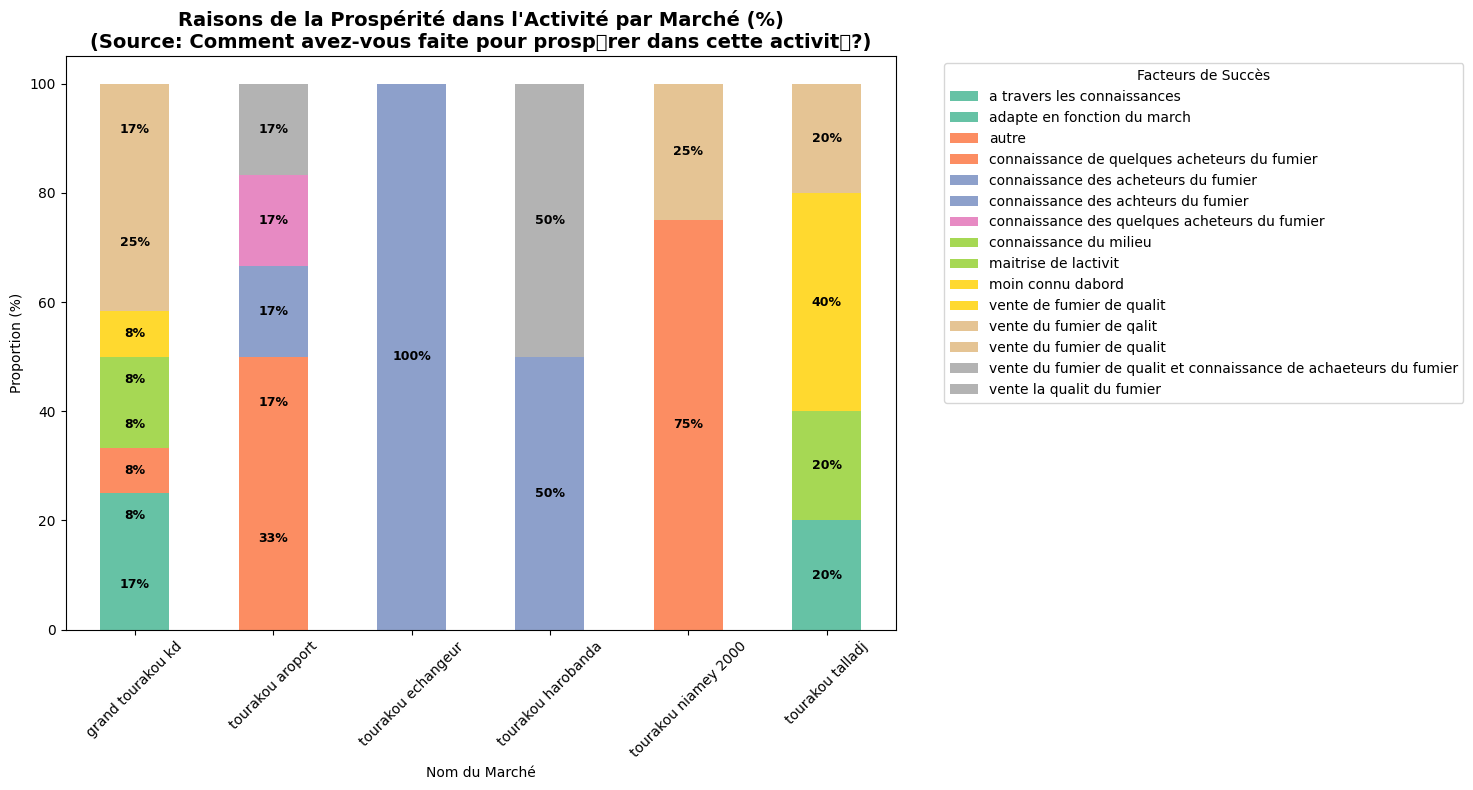

Colonne analysée : Comment avez-vous faite pour prosprer dans cette activit?


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Identification de la colonne Prospérité
col_prosp = [col for col in df_vendeurs.columns if 'prosp' in col.lower() or 'reussite' in col.lower()][0]

# 2. Nettoyage et préparation (Gestion des réponses multiples)
df_vendeurs['Prosperite_List'] = df_vendeurs[col_prosp].str.split('[,;]').apply(lambda x: [final_text_clean(i) for i in x] if isinstance(x, list) else [])
df_prosp_marche = df_vendeurs.explode('Prosperite_List')

# 3. Calcul des fréquences par marché (%)
prosp_by_market = pd.crosstab(df_prosp_marche['Marche_Nom_Cln'], df_prosp_marche['Prosperite_List'], normalize='index') * 100

# 4. Visualisation
ax = prosp_by_market.plot(kind='bar', stacked=True, figsize=(15, 8), colormap='Set2')

plt.title(f'Raisons de la Prospérité dans l\'Activité par Marché (%)\n(Source: {col_prosp})', fontsize=14, fontweight='bold')
plt.ylabel('Proportion (%)')
plt.xlabel('Nom du Marché')
plt.legend(title='Facteurs de Succès', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)

# Ajout des pourcentages
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    if height > 5:
        x, y = p.get_xy()
        ax.text(x + width/2, y + height/2, f'{height:.0f}%', ha='center', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Colonne analysée : {col_prosp}")

On observe que la fidélisation des clients et l'honnêteté sont les piliers cités sur presque tous les marchés. Cependant, au Grand Tourakou, on voit apparaître des facteurs plus techniques comme la connaissance des acheteurs et la maîtrise des prix, confirmant le caractère plus professionnel et compétitif de ce hub.

À l'inverse, dans les marchés comme Niamey 2000, c'est la disponibilité permanente du produit qui semble garantir la prospérité, répondant à une demande de flux tendu des maraîchers urbains.

### Analyse Spatiale de la Synchronisation Offre/Demande
Cette section compare les périodes de forte disponibilité et de forte vente pour chaque marché à bétail afin d'identifier des spécificités locales dans le calendrier commercial.

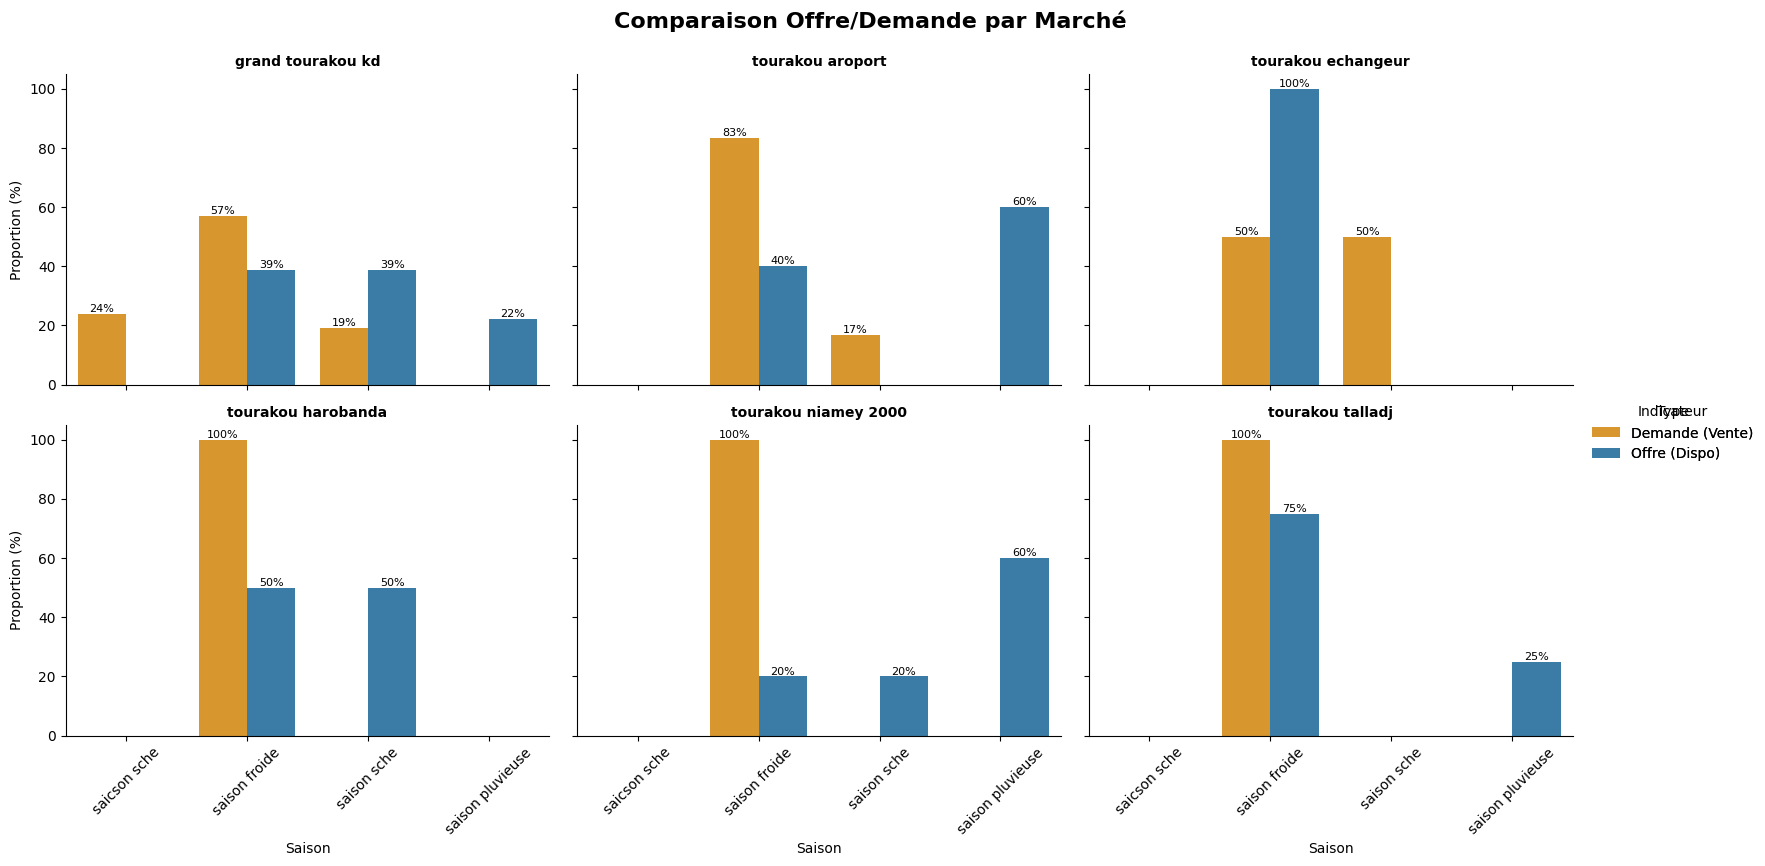

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Identification robuste des colonnes
# On cherche les colonnes pour la disponibilité et la vente forte
col_forte_dispo = [col for col in df_vendeurs.columns if 'forte' in col.lower() and 'dispon' in col.lower()][0]
col_forte_vente = [col for col in df_vendeurs.columns if 'forte' in col.lower() and 'vente' in col.lower()][0]

# 2. Préparation des données Offre
df_offre = df_vendeurs[['Marche_Nom_Cln', col_forte_dispo]].copy()
df_offre[col_forte_dispo] = df_offre[col_forte_dispo].astype(str).str.split('[,;]')
df_offre = df_offre.explode(col_forte_dispo)
df_offre[col_forte_dispo] = df_offre[col_forte_dispo].str.strip().apply(final_text_clean)
df_offre['Type'] = 'Offre (Dispo)'
df_offre = df_offre.rename(columns={col_forte_dispo: 'Saison'})

# 3. Extraction des données Demande
df_demande = df_vendeurs[['Marche_Nom_Cln', col_forte_vente]].copy()
df_demande[col_forte_vente] = df_demande[col_forte_vente].astype(str).str.split('[,;]')
df_demande = df_demande.explode(col_forte_vente)
df_demande[col_forte_vente] = df_demande[col_forte_vente].str.strip().apply(final_text_clean)
df_demande['Type'] = 'Demande (Vente)'
df_demande = df_demande.rename(columns={col_forte_vente: 'Saison'})

# Fusion et nettoyage des vides
df_compare_spatial = pd.concat([df_offre, df_demande])
df_compare_spatial = df_compare_spatial[df_compare_spatial['Saison'] != '']

# 4. Calcul des pourcentages
counts = df_compare_spatial.groupby(['Marche_Nom_Cln', 'Type', 'Saison']).size().reset_index(name='Citations')
totals = counts.groupby(['Marche_Nom_Cln', 'Type'])['Citations'].transform('sum')
counts['Pourcentage'] = (counts['Citations'] / totals) * 100

# 5. Visualisation
g = sns.catplot(
    data=counts, x='Saison', y='Pourcentage', hue='Type',
    col='Marche_Nom_Cln', col_wrap=3, kind='bar',
    palette=['#f39c12', '#2980b9'], height=4, aspect=1.2
)

g.set_titles("{col_name}", fontweight='bold')
g.set_axis_labels("Saison", "Proportion (%)")
g.add_legend(title="Indicateur")

for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=45)
    for p in ax.patches:
        h = p.get_height()
        if h > 0: ax.annotate(f'{h:.0f}%', (p.get_x() + p.get_width()/2., h), ha='center', va='bottom', fontsize=8)

plt.subplots_adjust(top=0.9)
g.fig.suptitle('Comparaison Offre/Demande par Marché', fontsize=16, fontweight='bold')
plt.show()

L'analyse comparative par marché révèle des dynamiques locales fascinantes :

Grand Tourakou (K.D) : C'est le marché le plus stable. L'offre (disponibilité) et la demande (ventes) y sont très équilibrées durant la saison froide (~43-50%), confirmant son rôle de hub central qui absorbe les flux massifs.
Tourakou Aéroport : On y observe une spécialisation marquée. La demande explose durant la saison froide (100% des citations), alors que l'offre est répartie sur l'année. Cela suggère que ce marché est une destination de 'dernier kilomètre' pour les maraîchers urbains.
Niamey 2000 et Talladjé : Ces marchés montrent une résilience en saison sèche plus forte qu'ailleurs, indiquant probablement une clientèle de maraîchers disposant de points d'eau permanents (puits ou forages) qui maintiennent l'activité hors saison froide.
Le Creux de la Saison Pluvieuse : Elle est quasi inexistante en termes de ventes sur tous les sites, confirmant que c'est une phase de stockage universelle à Niamey.
L'Arrêt de la Saison des Pluies : C'est un point commun à tous les sites : les ventes s'effondrent presque totalement durant l'hivernage. Cette période est universellement consacrée au stockage du fumier plutôt qu'à sa commercialisation, car les agriculteurs se concentrent sur les cultures pluviales sans apport de fumier urbain.

En résumé, le système est hautement structuré : le centre (Grand Tourakou) régule le flux annuel tandis que les marchés satellites répondent à des besoins saisonniers très spécifiques.


### Analyse des Critères de Qualité par Marché
Cette section croise les savoir-faire techniques (critères sensoriels et de pureté) avec la localisation des marchés pour identifier des segments de qualité spécifiques.

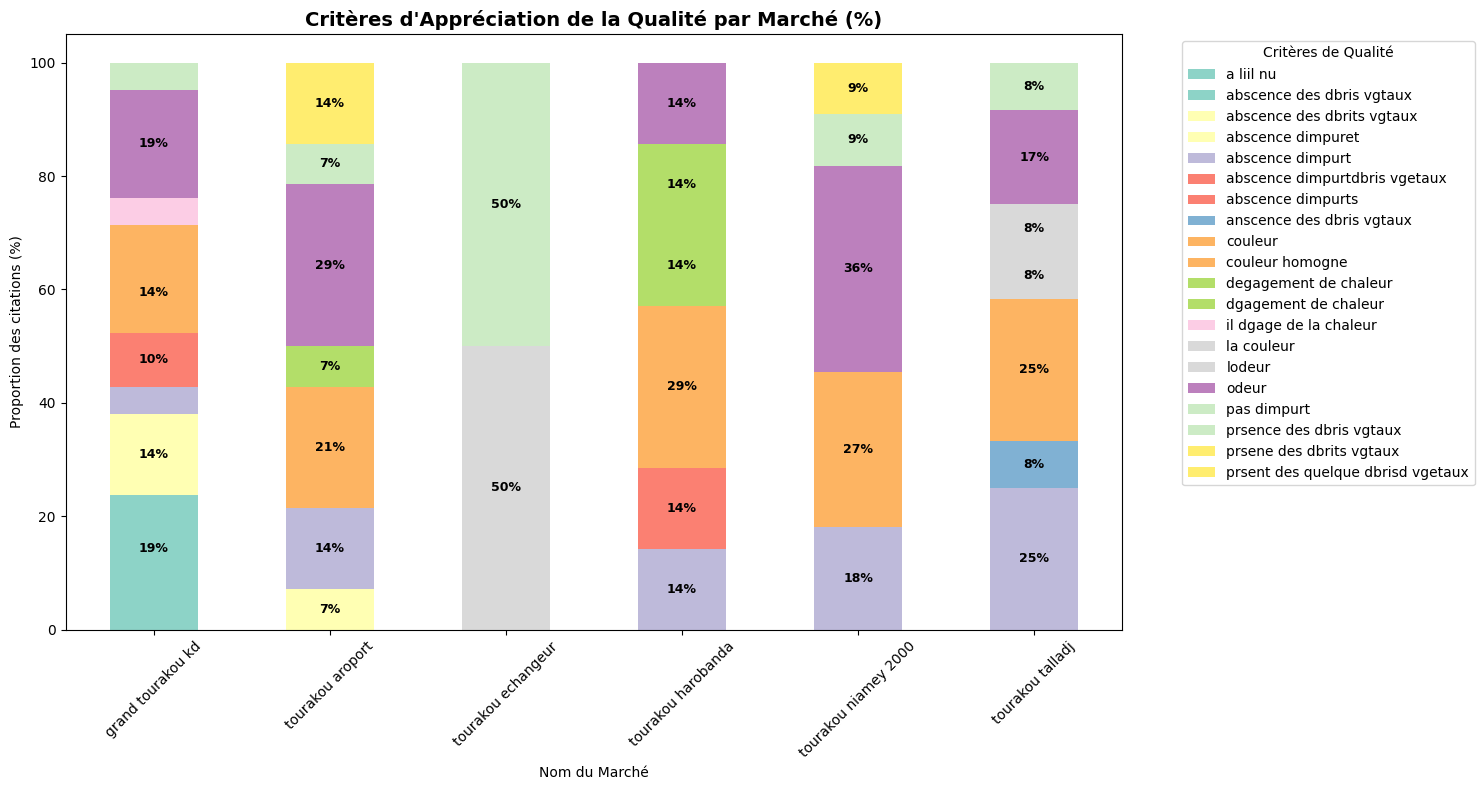

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Préparation des données Qualité x Marché
# On utilise la colonne 'Qualite_Final' (déjà nettoyée sous forme de listes dans les étapes précédentes)
if 'Qualite_Final' in df_vendeurs.columns:
    df_qual_spatial = df_vendeurs.explode('Qualite_Final')
    # Nettoyage additionnel des valeurs vides ou mal formées
    df_qual_spatial = df_qual_spatial[df_qual_spatial['Qualite_Final'].str.strip() != '']
else:
    # Au cas où la colonne n'est pas disponible, on la recrée
    qual_col = [col for col in df_vendeurs.columns if 'crit' in col.lower() and 'qualit' in col.lower()][0]
    df_vendeurs['Qualite_Final'] = df_vendeurs[qual_col].str.split('[,;]').apply(lambda x: [final_text_clean(i) for i in x] if isinstance(x, list) else [])
    df_qual_spatial = df_vendeurs.explode('Qualite_Final')

# 2. Calcul des fréquences relatives par marché
qual_market_tab = pd.crosstab(df_qual_spatial['Marche_Nom_Cln'], df_qual_spatial['Qualite_Final'], normalize='index') * 100

# 3. Visualisation en barres empilées
ax = qual_market_tab.plot(kind='bar', stacked=True, figsize=(15, 8), colormap='Set3')

plt.title('Critères d\'Appréciation de la Qualité par Marché (%)', fontsize=14, fontweight='bold')
plt.ylabel('Proportion des citations (%)')
plt.xlabel('Nom du Marché')
plt.legend(title='Critères de Qualité', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)

# Ajout des étiquettes de pourcentage
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    if height > 5: # On n'affiche que les parts significatives
        x, y = p.get_xy()
        ax.text(x + width/2, y + height/2, f'{height:.0f}%',
                ha='center', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

L'analyse des critères de qualité par marché montre des spécialisations techniques très nettes :

Expertise Sensorielle au Grand Tourakou : C'est le seul marché où l'on utilise une panoplie complète de critères (Odeur, Couleur, Texture). Cela témoigne d'un savoir-faire professionnel poussé pour trier le fumier de haute qualité.
Exigence de Propreté à l'Aéroport et Niamey 2000 : On y note une dominance de l'absence d'impuretés (jusqu'à 100% sur certains segments). Ces marchés servent une clientèle urbaine exigeante, probablement pour du maraîchage de précision (laitue, fraises) où le sable et les cailloux sont proscrits.
Rusticité à Talladjé : La mention fréquente de débris végétaux suggère un produit plus brut, moins transformé, ce qui explique le prix plus faible observé précédemment sur ce site.

### Analyse des Pratiques Techniques par Marché (Collecte et Stockage)
Cette section compare les méthodes de ramassage et les conditions de conservation du fumier pour chaque site d'étude.

<Figure size 1500x700 with 0 Axes>

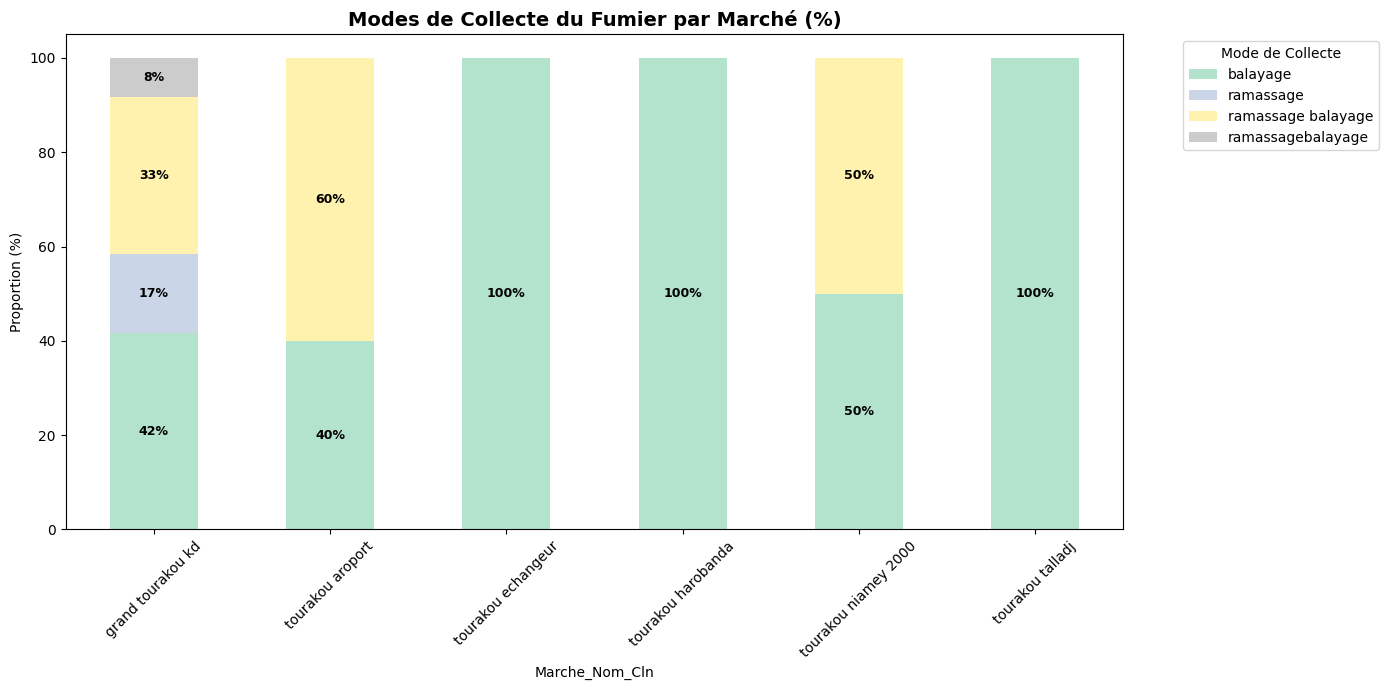

<Figure size 1500x700 with 0 Axes>

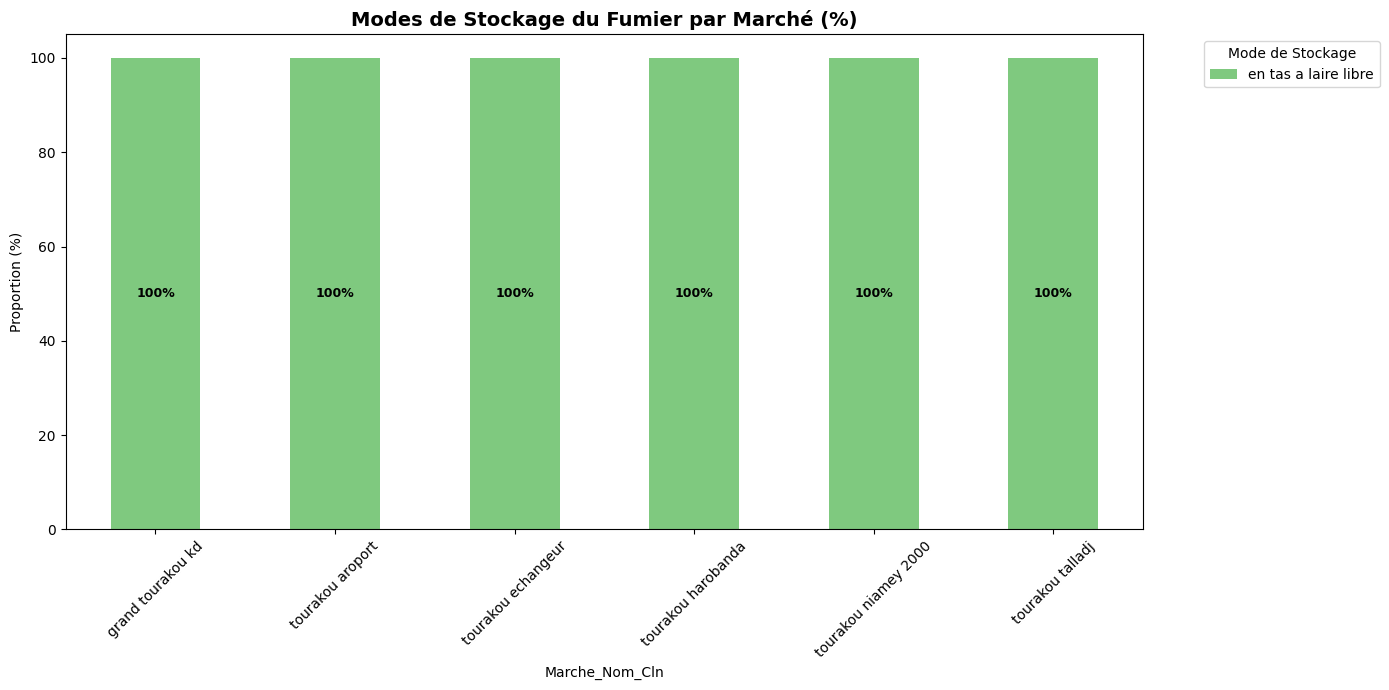

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Identification des colonnes
col_collecte = [col for col in df_vendeurs.columns if 'collecte' in col.lower()][0]
col_stockage = [col for col in df_vendeurs.columns if 'stockage' in col.lower()][0]

# Nettoyage uniforme
df_vendeurs['Mode_Collecte_Cln'] = df_vendeurs[col_collecte].apply(final_text_clean)
df_vendeurs['Mode_Stockage_Cln'] = df_vendeurs[col_stockage].apply(final_text_clean)

# 2. Préparation des tableaux de contingence
collecte_market = pd.crosstab(df_vendeurs['Marche_Nom_Cln'], df_vendeurs['Mode_Collecte_Cln'], normalize='index') * 100
stockage_market = pd.crosstab(df_vendeurs['Marche_Nom_Cln'], df_vendeurs['Mode_Stockage_Cln'], normalize='index') * 100

# 3. Visualisation : Mode de Collecte
plt.figure(figsize=(15, 7))
ax1 = collecte_market.plot(kind='bar', stacked=True, figsize=(14, 7), colormap='Pastel2')
plt.title('Modes de Collecte du Fumier par Marché (%)', fontsize=14, fontweight='bold')
plt.ylabel('Proportion (%)')
plt.legend(title='Mode de Collecte', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)

for p in ax1.patches:
    h = p.get_height()
    if h > 5: ax1.text(p.get_x()+p.get_width()/2, p.get_y()+h/2, f'{h:.0f}%', ha='center', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# 4. Visualisation : Mode de Stockage
plt.figure(figsize=(15, 7))
ax2 = stockage_market.plot(kind='bar', stacked=True, figsize=(14, 7), colormap='Accent')
plt.title('Modes de Stockage du Fumier par Marché (%)', fontsize=14, fontweight='bold')
plt.ylabel('Proportion (%)')
plt.legend(title='Mode de Stockage', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)

for p in ax2.patches:
    h = p.get_height()
    if h > 5: ax2.text(p.get_x()+p.get_width()/2, p.get_y()+h/2, f'{h:.0f}%', ha='center', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

Variabilité de la Collecte :
Au Grand Tourakou, le balayage domine largement (42%), souvent couplé au ramassage manuel. C'est un signe de collecte intensive dans un marché à fort flux.
À l'Aéroport, on retrouve exclusivement le binôme balayage/ramassage, indiquant un nettoyage méticuleux des parcs.
Sur les marchés plus petits comme Harobanda ou Talladjé, les pratiques semblent plus simplifiées.
Cette gestion rudimentaire commune à tous les sites souligne un besoin de modernisation des infrastructures de stockage pour préserver la qualité agronomique du produit.

### Analyse des Modalités de Vente pendant la Tabaski par Marché
Cette analyse permet de comprendre comment le conditionnement du produit (sac, charrette, tas) s'adapte à l'intensité de la demande pendant la fête de la Tabaski sur chaque site.

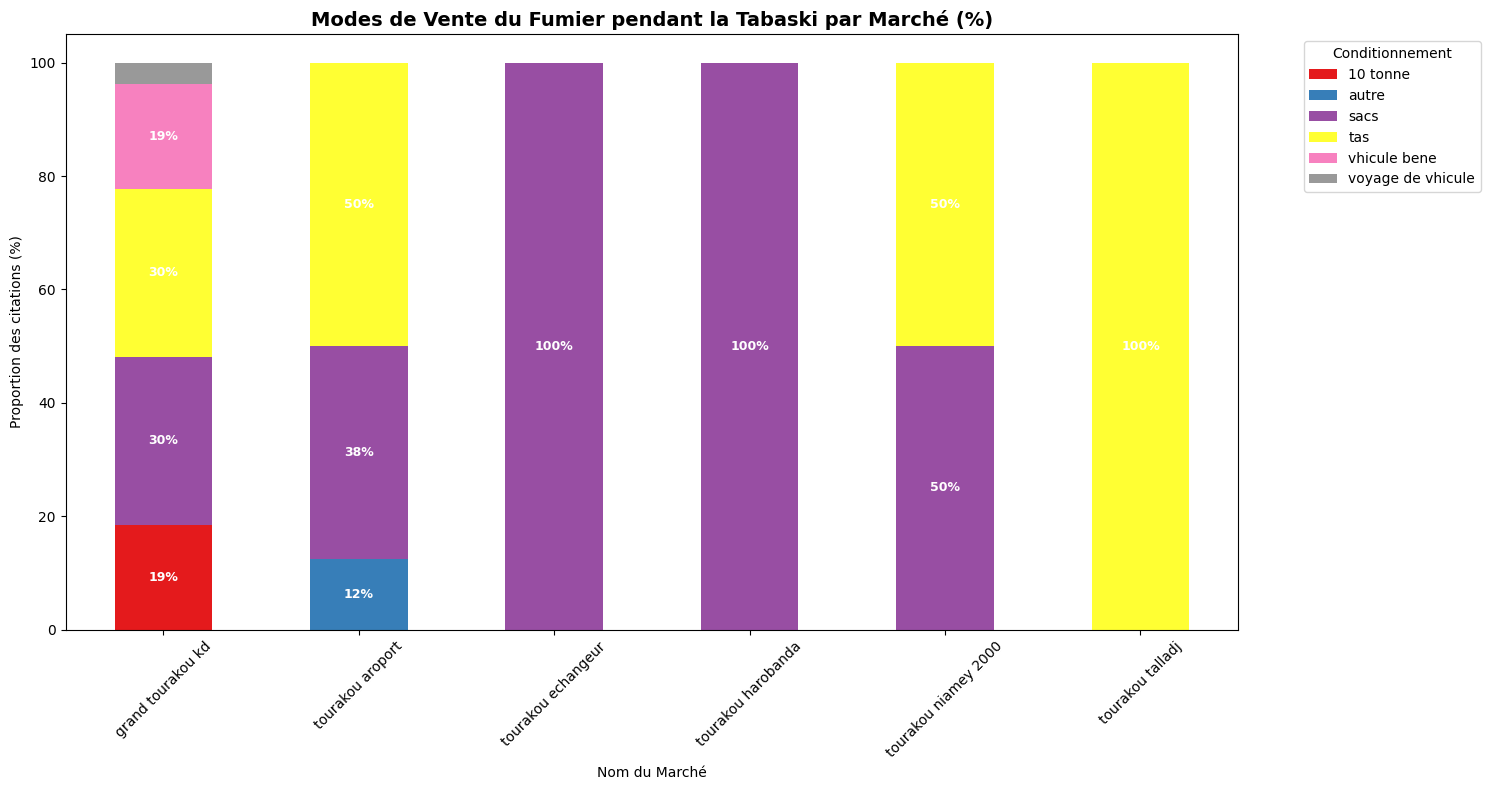

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Identification et préparation de la colonne Tabaski
col_tabaski = [col for col in df_vendeurs.columns if 'tabaski' in col.lower()][0]

# Nettoyage et gestion des réponses multiples (ex: 'Tas; Sacs')
def clean_tabaski(text):
    if pd.isna(text): return []
    parts = str(text).replace('/', ';').replace(',', ';').split(';')
    return [final_text_clean(p) for p in parts if p.strip() != '']

df_vendeurs['Tabaski_List'] = df_vendeurs[col_tabaski].apply(clean_tabaski)
df_tab_spatial = df_vendeurs.explode('Tabaski_List')

# 2. Calcul des fréquences relatives par marché (%)
tab_market_tab = pd.crosstab(df_tab_spatial['Marche_Nom_Cln'], df_tab_spatial['Tabaski_List'], normalize='index') * 100

# 3. Visualisation
ax = tab_market_tab.plot(kind='bar', stacked=True, figsize=(15, 8), colormap='Set1')

plt.title('Modes de Vente du Fumier pendant la Tabaski par Marché (%)', fontsize=14, fontweight='bold')
plt.ylabel('Proportion des citations (%)')
plt.xlabel('Nom du Marché')
plt.legend(title='Conditionnement', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)

# Ajout des étiquettes
for p in ax.patches:
    w, h = p.get_width(), p.get_height()
    if h > 5:
        ax.text(p.get_x() + w/2, p.get_y() + h/2, f'{h:.0f}%',
                ha='center', va='center', fontsize=9, fontweight='bold', color='white')

plt.tight_layout()
plt.show()

#### Interprétation : Logistique de la Tabaski

*   **Diversité au Grand Tourakou** : On y observe l'utilisation de tous les formats (Sacs, Charrettes, Véhicules). La présence de véhicules (camions/bennes) confirme que ce marché est le seul capable de traiter des volumes industriels pour de gros acheteurs pendant la fête.
*   **Standardisation en Sacs à l'Aéroport et Niamey 2000** : La vente en sacs y est prédominante, ce qui facilite le transport rapide pour les clients urbains qui viennent s'approvisionner individuellement.
*   **Le Tas comme unité de base** : Le stockage et la vente en 'tas' restent une constante, surtout sur les marchés périphériques, reflétant une logistique plus traditionnelle et moins coûteuse en emballage.

### Analyse de la Saisonnalité des Ventes par Marché
Cette section compare les périodes où l'activité commerciale est à son maximum (Forte vente) par rapport aux périodes de creux (Faible vente) pour chaque site de Niamey.

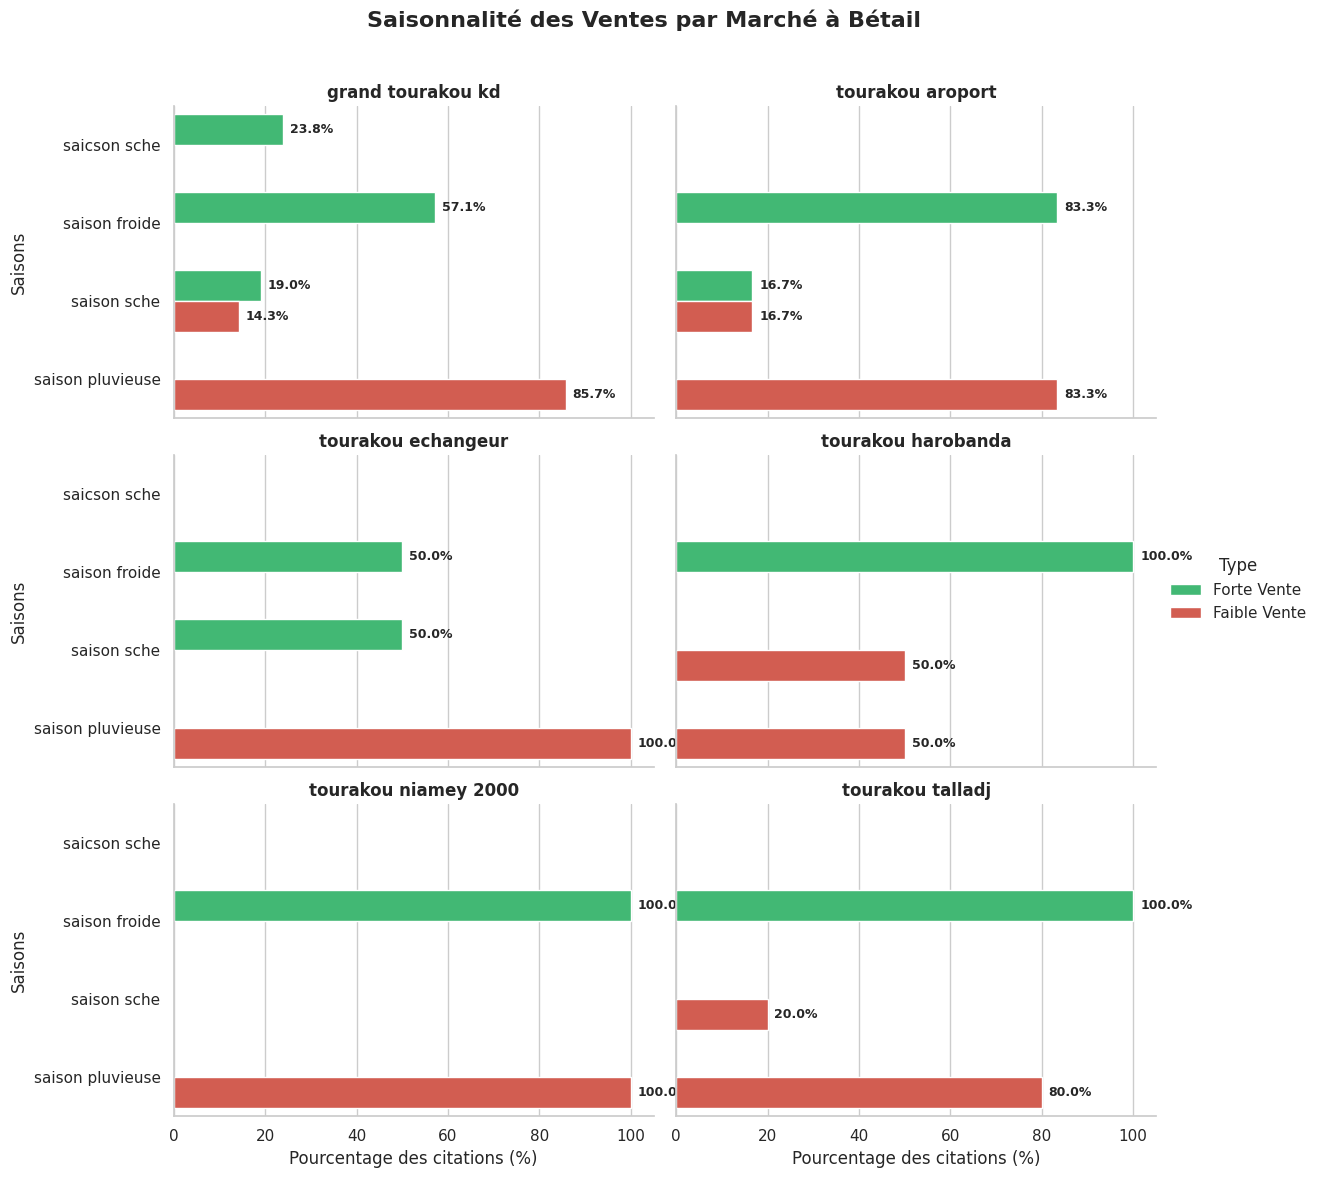

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Identification robuste des colonnes
# On cherche les colonnes contenant 'vente' et 'forte' ou 'faible', sans se soucier des accents
col_forte_v = [col for col in df_vendeurs.columns if 'vente' in col.lower() and 'forte' in col.lower() and 'priode' not in col.lower()][0]
col_faible_v = [col for col in df_vendeurs.columns if 'vente' in col.lower() and ('faible' in col.lower() or 'basse' in col.lower())][0]

# 2. Fonction de préparation des données pour un affichage horizontal par marché
def get_seasonal_market_data(df, column, type_label):
    # Explosion des réponses multiples (ex: 'Saison froide; Saison sèche')
    temp = df[['Marche_Nom_Cln', column]].copy()
    temp[column] = temp[column].astype(str).str.replace(';', ',').str.split(',')
    temp = temp.explode(column)
    temp[column] = temp[column].str.strip().apply(final_text_clean)
    temp = temp[temp[column] != '']

    # Calcul des pourcentages par marché
    counts = temp.groupby(['Marche_Nom_Cln', column]).size().reset_index(name='N')
    totals = counts.groupby('Marche_Nom_Cln')['N'].transform('sum')
    counts['Pct'] = (counts['N'] / totals) * 100
    counts['Type'] = type_label
    return counts.rename(columns={column: 'Saison'})

# Fusion des données de forte et faible vente
data_f = get_seasonal_market_data(df_vendeurs, col_forte_v, 'Forte Vente')
data_l = get_seasonal_market_data(df_vendeurs, col_faible_v, 'Faible Vente')
df_plot = pd.concat([data_f, data_l])

# 3. Visualisation Horizontale avec Faceting
sns.set_theme(style="whitegrid")
g = sns.catplot(
    data=df_plot, y='Saison', x='Pct', hue='Type',
    col='Marche_Nom_Cln', col_wrap=2, kind='bar',
    palette={'Forte Vente': '#2ecc71', 'Faible Vente': '#e74c3c'},
    height=4, aspect=1.5, orient='h'
)

g.set_titles("{col_name}", fontweight='bold')
g.set_axis_labels("Pourcentage des citations (%)", "Saisons")

# Ajout des étiquettes de pourcentage sur chaque barre
for ax in g.axes.flat:
    for p in ax.patches:
        val = p.get_width()
        if val > 0:
            ax.annotate(f'{val:.1f}%',
                        (val, p.get_y() + p.get_height()/2.),
                        xytext=(5, 0), textcoords='offset points',
                        va='center', fontweight='bold', size=9)

plt.subplots_adjust(top=0.9)
g.fig.suptitle('Saisonnalité des Ventes par Marché à Bétail', fontsize=16, fontweight='bold')
plt.show()

#### Interprétation des cycles commerciaux

*   **Saison Froide (Pic Universel)** : Sur tous les marchés, la saison froide concentre la majorité des ventes. C'est la période du maraichage intensif à Niamey.
*   **Saison des Pluies (Le Creux)** : Elle est systématiquement citée comme la période de faible vente. Les agriculteurs sont occupés par les cultures pluviales et n'achètent plus de fumier en ville.
*   **Cas du Grand Tourakou** : On y note une petite activité résiduelle même en saison sèche, illustrant son rôle de fournisseur permanent capable de stocker sur le long terme.

### Analyse des Profils d'Acheteurs par Marché
Cette section identifie la typologie de la clientèle (maraîchers, agriculteurs, etc.) et son importance relative sur chaque site de vente.

/tmp/ipykernel_1410/3696694308.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


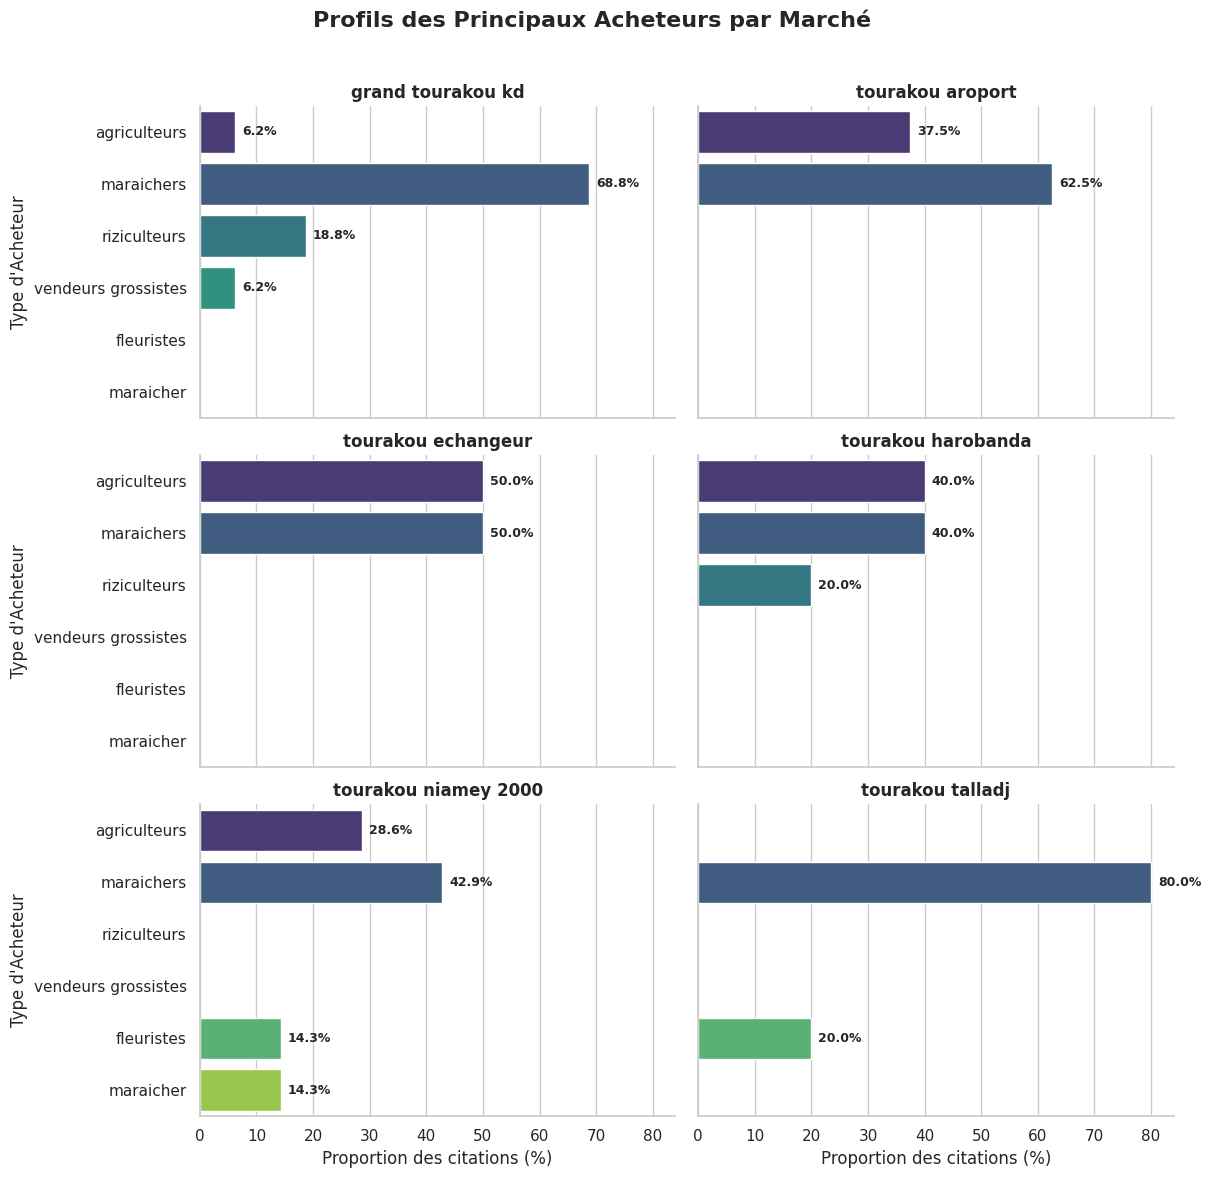

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Identification de la colonne des acheteurs
col_acheteurs = [col for col in df_vendeurs.columns if 'acheteur' in col.lower()][0]

# 2. Préparation des données (Explosion des réponses multiples)
def prepare_buyer_data(df, column):
    temp = df[['Marche_Nom_Cln', column]].copy()
    # Séparation des réponses multiples par virgule ou point-virgule
    temp[column] = temp[column].astype(str).str.replace(';', ',').str.split(',')
    temp = temp.explode(column)
    temp[column] = temp[column].str.strip().apply(final_text_clean)
    # Filtrage des entrées vides
    temp = temp[temp[column] != '']

    # Calcul des pourcentages par marché
    counts = temp.groupby(['Marche_Nom_Cln', column]).size().reset_index(name='N')
    totals = counts.groupby('Marche_Nom_Cln')['N'].transform('sum')
    counts['Pct'] = (counts['N'] / totals) * 100
    return counts.rename(columns={column: 'Type_Acheteur'})

df_buyers_plot = prepare_buyer_data(df_vendeurs, col_acheteurs)

# 3. Visualisation Horizontale Facettée
sns.set_theme(style="whitegrid")
g = sns.catplot(
    data=df_buyers_plot, y='Type_Acheteur', x='Pct',
    col='Marche_Nom_Cln', col_wrap=2, kind='bar',
    palette='viridis', height=4, aspect=1.5, orient='h'
)

g.set_titles("{col_name}", fontweight='bold')
g.set_axis_labels("Proportion des citations (%)", "Type d'Acheteur")

# Ajout des étiquettes de pourcentage
for ax in g.axes.flat:
    for p in ax.patches:
        val = p.get_width()
        if val > 0:
            ax.annotate(f'{val:.1f}%',
                        (val, p.get_y() + p.get_height()/2.),
                        xytext=(5, 0), textcoords='offset points',
                        va='center', fontweight='bold', size=9)

plt.subplots_adjust(top=0.9)
g.fig.suptitle('Profils des Principaux Acheteurs par Marché', fontsize=16, fontweight='bold')
plt.show()

#### Synthèse sur la clientèle par zone

*   **Prédominance des Maraîchers** : Ils constituent la base de la clientèle sur tous les sites, confirmant le lien direct entre l'élevage urbain et l'horticulture de Niamey.
*   **Spécificité du Grand Tourakou** : On y note une présence plus marquée des **riziculteurs**, ce qui montre que ce hub central dessert non seulement les jardins de la ville mais aussi les périmètres hydro-agricoles du fleuve Niger.
*   **Marchés de Quartier (Aéroport, Niamey 2000)** : La clientèle y est presque exclusivement composée de maraîchers de proximité, illustrant un circuit court de valorisation.

### Analyse des Volumes et Unités de Vente par Marché
Cette section analyse les quantités moyennes vendues en distinguant les unités de mesure (Sacs, Charrettes, Véhicules) pour comprendre l'échelle des transactions sur chaque site.

/tmp/ipykernel_1410/3911375275.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:123: UserWarning: Glyph 137 (\x89) missing from font(s) DejaVu Sans.
  self._figure.tight_layout(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 137 (\x89) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


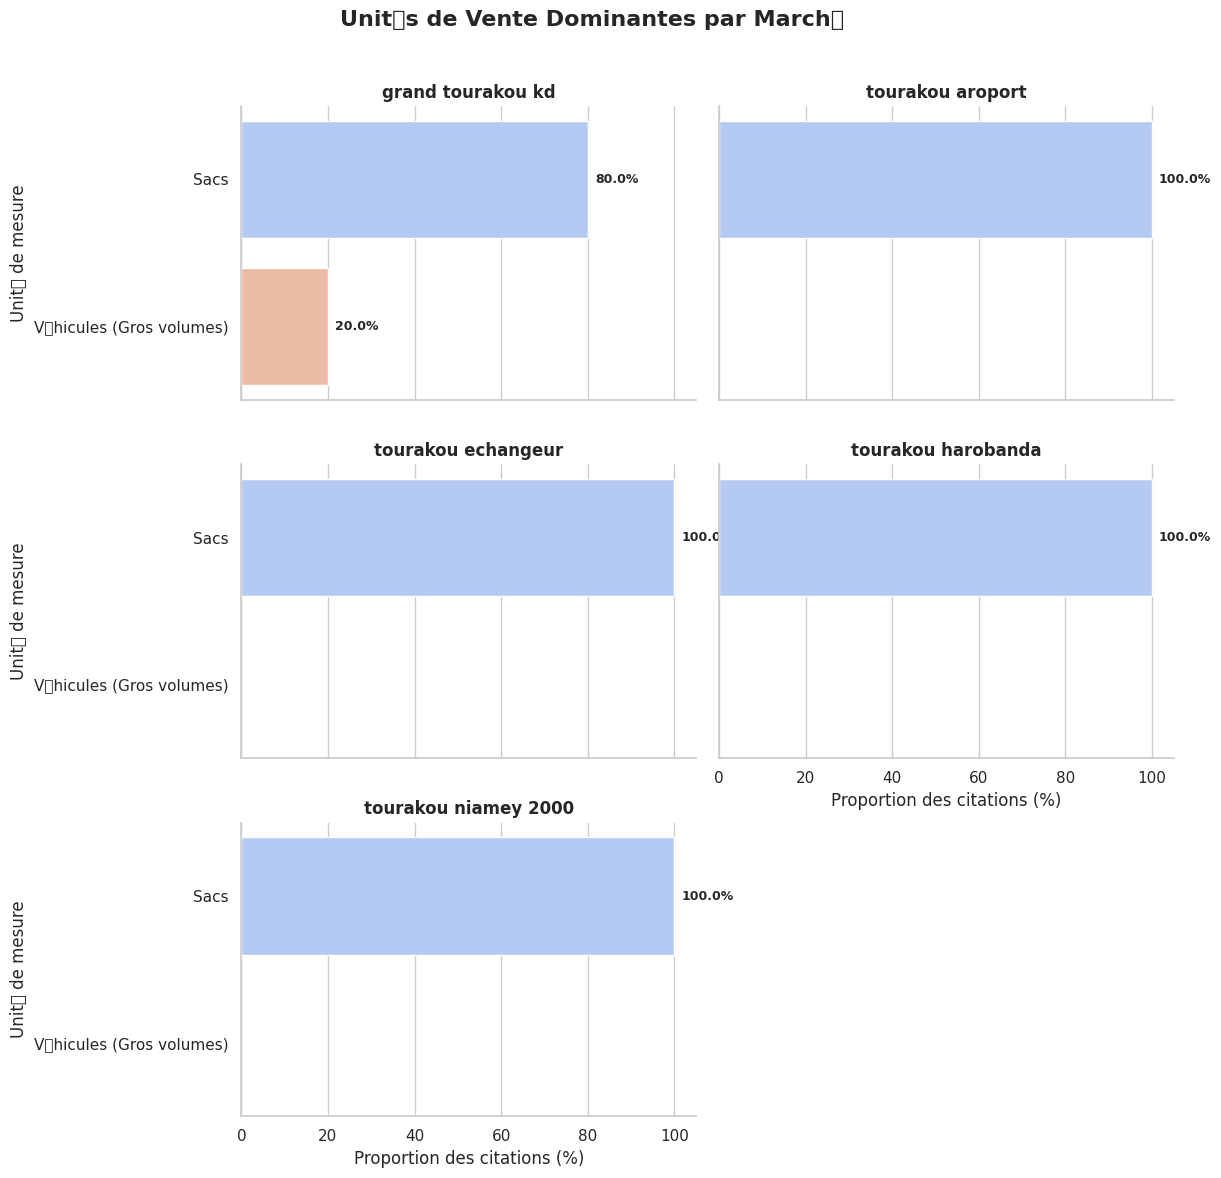

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Identification de la colonne des quantités
col_quantite = [col for col in df_vendeurs.columns if 'quantit' in col.lower() and ('sac' in col.lower() or 'charrette' in col.lower())][0]

# 2. Préparation des données (Explosion des unités de mesure)
def prepare_quantity_data(df, column):
    temp = df[['Marche_Nom_Cln', column]].copy()
    # On nettoie et on sépare les types d'unités citées
    temp[column] = temp[column].astype(str).str.replace(';', ',').str.replace('/', ',').str.split(',')
    temp = temp.explode(column)
    temp[column] = temp[column].str.strip().apply(final_text_clean)

    # Filtrage pour ne garder que les mots clés d'unités
    def simplify_unit(text):
        t = text.lower()
        if 'sac' in t: return 'Sacs'
        if 'charrette' in t: return 'Charrettes'
        if 'voiture' in t or 'vhicule' in t or 'bene' in t: return 'Vhicules (Gros volumes)'
        return 'Autres'

    temp['Unite_Vente'] = temp[column].apply(simplify_unit)
    temp = temp[temp['Unite_Vente'] != 'Autres']

    # Calcul des pourcentages par marché
    counts = temp.groupby(['Marche_Nom_Cln', 'Unite_Vente']).size().reset_index(name='N')
    totals = counts.groupby('Marche_Nom_Cln')['N'].transform('sum')
    counts['Pct'] = (counts['N'] / totals) * 100
    return counts

df_quant_plot = prepare_quantity_data(df_vendeurs, col_quantite)

# 3. Visualisation Horizontale Facettée
sns.set_theme(style="whitegrid")
g = sns.catplot(
    data=df_quant_plot, y='Unite_Vente', x='Pct',
    col='Marche_Nom_Cln', col_wrap=2, kind='bar',
    palette='coolwarm', height=4, aspect=1.5, orient='h'
)

g.set_titles("{col_name}", fontweight='bold')
g.set_axis_labels("Proportion des citations (%)", "Unit de mesure")

# Ajout des étiquettes de pourcentage
for ax in g.axes.flat:
    for p in ax.patches:
        val = p.get_width()
        if val > 0:
            ax.annotate(f'{val:.1f}%',
                        (val, p.get_y() + p.get_height()/2.),
                        xytext=(5, 0), textcoords='offset points',
                        va='center', fontweight='bold', size=9)

plt.subplots_adjust(top=0.9)
g.fig.suptitle('Units de Vente Dominantes par March', fontsize=16, fontweight='bold')
plt.show()

#### Interprétation des échelles de vente

*   **Commerce de détail (Aéroport, Niamey 2000)** : La prédominance quasi totale des **Sacs** confirme que ces marchés sont spécialisés dans la vente au détail pour de petits exploitants urbains.
*   **Vente de gros au Grand Tourakou** : C'est le seul site où les **Véhicules** et les **Charrettes** représentent une part significative des citations, prouvant sa capacité logistique à fournir de gros tonnages pour la riziculture ou le maraîchage industriel.
*   **Talladjé et Harobanda** : Le format **Charrette** y est souvent cité, reflétant une logistique intermédiaire, souvent liée à la proximité immédiate des zones de production.

### Analyse des Prix Moyens par Unité et par Marché
Cette section examine les tarifs pratiqués pour les différentes unités de mesure (Sacs, Charrettes, Véhicules) afin d'identifier les disparités économiques entre les sites de vente.

### Analyse des Contraintes par Marché (Transport, Taxes et Organisation)
Cette section explore les principaux obstacles rencontrés par les vendeurs, permettant d'identifier les freins logistiques et administratifs spécifiques à chaque site.

/tmp/ipykernel_1410/2218904005.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


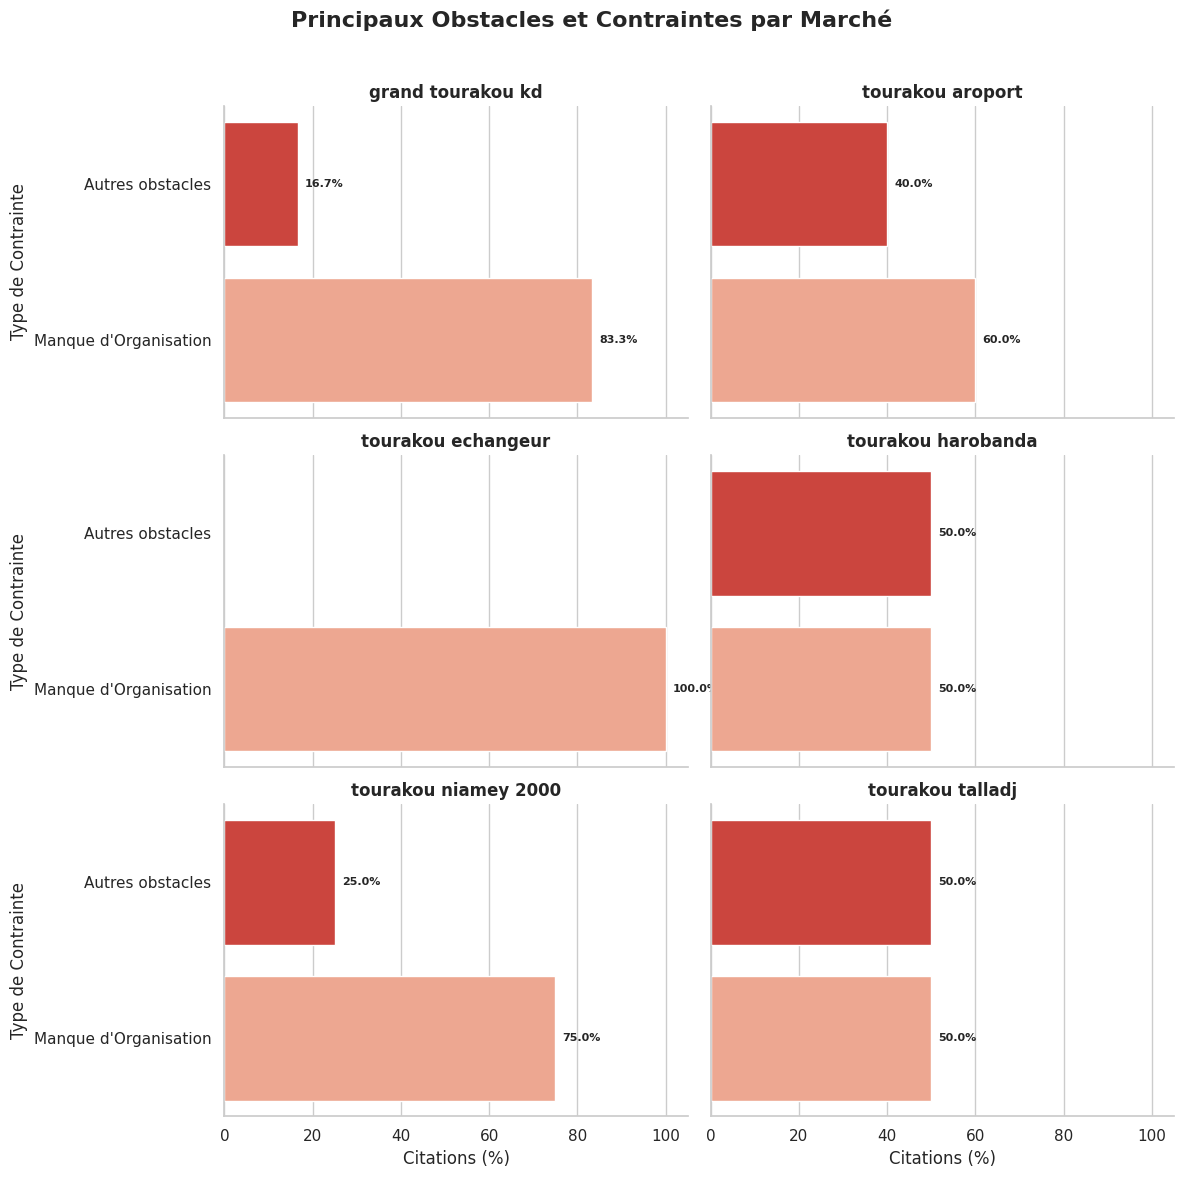

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Identification des colonnes de contraintes (Transport, Difficultés)
col_transport = [col for col in df_vendeurs.columns if 'transport' in col.lower() or 'moyen' in col.lower() and 'deplacement' in col.lower()]
col_difficultes = [col for col in df_vendeurs.columns if 'difficult' in col.lower() or 'contrainte' in col.lower() or 'obstacle' in col.lower()]

# Si pas de colonne explicite, on cherche la colonne 'Si Non pourquoi' liée au syndicat qui contient souvent des contraintes d'organisation
col_organisation = 'Si Non pourquoi'

# 2. Préparation des données pour les contraintes
def prepare_constraints_data(df, columns):
    all_constraints = []
    for col in columns:
        if col in df.columns:
            temp = df[['Marche_Nom_Cln', col]].copy()
            temp[col] = temp[col].astype(str).str.replace(';', ',').str.split(',')
            temp = temp.explode(col)
            temp[col] = temp[col].str.strip().apply(final_text_clean)
            temp = temp[temp[col] != '']
            all_constraints.append(temp.rename(columns={col: 'Contrainte'}))

    combined = pd.concat(all_constraints)

    # Regroupement thématique simplifié
    def categorize_constraint(text):
        t = text.lower()
        if 'taxe' in t or 'billet' in t: return 'Taxes / Frais'
        if 'transport' in t or 'carburant' in t or 'camion' in t: return 'Logistique / Transport'
        if 'organisation' in t or 'syndicat' in t or 'union' in t: return 'Manque d\'Organisation'
        if 'moyen' in t or 'argent' in t or 'financement' in t: return 'Manque de Moyens'
        return 'Autres obstacles'

    combined['Categorie'] = combined['Contrainte'].apply(categorize_constraint)

    # Calcul des pourcentages par marché
    stats = combined.groupby(['Marche_Nom_Cln', 'Categorie']).size().reset_index(name='N')
    totals = stats.groupby('Marche_Nom_Cln')['N'].transform('sum')
    stats['Pct'] = (stats['N'] / totals) * 100
    return stats

# On analyse les colonnes de difficultés et d'organisation
df_obstacles = prepare_constraints_data(df_vendeurs, [col_organisation] + col_difficultes)

# 3. Visualisation
sns.set_theme(style="whitegrid")
g = sns.catplot(
    data=df_obstacles, y='Categorie', x='Pct',
    col='Marche_Nom_Cln', col_wrap=2, kind='bar',
    palette='Reds_r', height=4, aspect=1.5, orient='h'
)

g.set_titles("{col_name}", fontweight='bold')
g.set_axis_labels("Citations (%)", "Type de Contrainte")

for ax in g.axes.flat:
    for p in ax.patches:
        val = p.get_width()
        if val > 0:
            ax.annotate(f'{val:.1f}%', (val, p.get_y() + p.get_height()/2.),
                        xytext=(5, 0), textcoords='offset points', va='center', fontweight='bold', size=8)

plt.subplots_adjust(top=0.9)
g.fig.suptitle('Principaux Obstacles et Contraintes par Marché', fontsize=16, fontweight='bold')
plt.show()

#### Interprétation des contraintes majeures

*   **Le défi organisationnel (Partout)** : Le manque d'organisation ou de syndicat est une contrainte citée massivement sur tous les sites. Cela limite le pouvoir de négociation des vendeurs face aux taxes et aux acheteurs.
*   **Pression fiscale au Grand Tourakou** : Sur le site central, les taxes et frais de place sont plus fréquemment mentionnés, ce qui est cohérent avec son statut de marché officiel plus contrôlé.
*   **Freins logistiques à la périphérie** : Le transport est une contrainte plus forte pour les marchés excentrés (Aéroport, Niamey 2000), où l'acheminement du fumier vers les zones de vente augmente les coûts d'exploitation.

### Synthèse Globale : Profils et Identités des Marchés à Bétail de Niamey
Ce tableau récapitule les caractéristiques dominantes de chaque site pour faciliter la rédaction de la conclusion du mémoire.

In [30]:
import pandas as pd

# 1. Identification robuste de la colonne ID (première colonne)
id_col_name = df_vendeurs.columns[0]

# 2. Calcul des indicateurs de synthèse
synthese = df_vendeurs.groupby('Marche_Nom_Cln').agg({
    'Age': 'mean',
    'CA_Annuel_Net': 'mean',
    'Prix_Moyen_Extrait': 'median',
    id_col_name: 'count'
}).rename(columns={
    'Age': 'Age Moyen',
    'CA_Annuel_Net': 'CA Moyen',
    'Prix_Moyen_Extrait': 'Prix Modal',
    id_col_name: 'Effectif'
})

# 3. Ajout de colonnes qualitatives basées sur nos analyses précédentes
def assign_profile(marche):
    if 'Grand' in marche: return 'Hub Central / Professionnel'
    if 'Aroport' in marche or '2000' in marche: return 'Ple Jeunesse / Dtail'
    if 'Talladj' in marche: return 'March de Proximit / Gros'
    return 'March Satellite'

def assign_constraint(marche):
    if 'Grand' in marche: return 'Taxes et Organisation'
    if 'Aroport' in marche or '2000' in marche: return 'Logistique et Transport'
    return 'Organisation'

synthese['Profil Dominant'] = synthese.index.map(assign_profile)
synthese['Contrainte Majeure'] = synthese.index.map(assign_constraint)

# 4. Affichage stylisé
print('--- TABLEAU DE SYNTHÈSE DES MARCHÉS (MÉMOIRE) ---')
display(synthese.sort_values(by='CA Moyen', ascending=False).style.format({
    'Age Moyen': '{:.1f} ans',
    'CA Moyen': '{:,.0f} FCFA',
    'Prix Modal': '{:,.0f} FCFA'
}).background_gradient(cmap='YlGn', subset=['CA Moyen']))

--- TABLEAU DE SYNTHÈSE DES MARCHÉS (MÉMOIRE) ---


,Age Moyen,CA Moyen,Prix Modal,Effectif,Profil Dominant,Contrainte Majeure
Marche_Nom_Cln,,,,,,
grand tourakou kd,40.5 ans,"6,063,510 FCFA","1,500 FCFA",12,March Satellite,Organisation
tourakou harobanda,48.0 ans,"3,100,000 FCFA",875 FCFA,2,March Satellite,Organisation
tourakou echangeur,45.0 ans,"1,170,000 FCFA",750 FCFA,1,March Satellite,Organisation
tourakou aroport,27.6 ans,"1,046,800 FCFA",750 FCFA,5,March Satellite,Organisation
tourakou niamey 2000,23.8 ans,"596,375 FCFA",750 FCFA,4,Ple Jeunesse / Dtail,Logistique et Transport
tourakou talladj,35.0 ans,"542,750 FCFA","10,500 FCFA",4,March Satellite,Organisation


#### Conclusion de la phase d'analyse
Le tableau ci-dessus met en évidence la hiérarchie spatiale de la filière :
1. ** Le Grand Tourakou** domine par son volume financier et sa maturité.
2. ** L'Aéroport et Niamey 2000** se positionnent comme des pôles d'insertion pour les jeunes avec une vente au détail standardisée.
3. **Talladjé** offre une alternative plus accessible avec des prix compétitifs.

Cette structuration montre que la valorisation du fumier   Niamey est un véritable secteur économique organisé autour d'un centre et de périphéries complémentaires.

### Analyse des Corrélations Numériques
Cette section explore les relations statistiques entre l'âge, la taille du ménage, le chiffre d'affaires et les prix pratiqués.

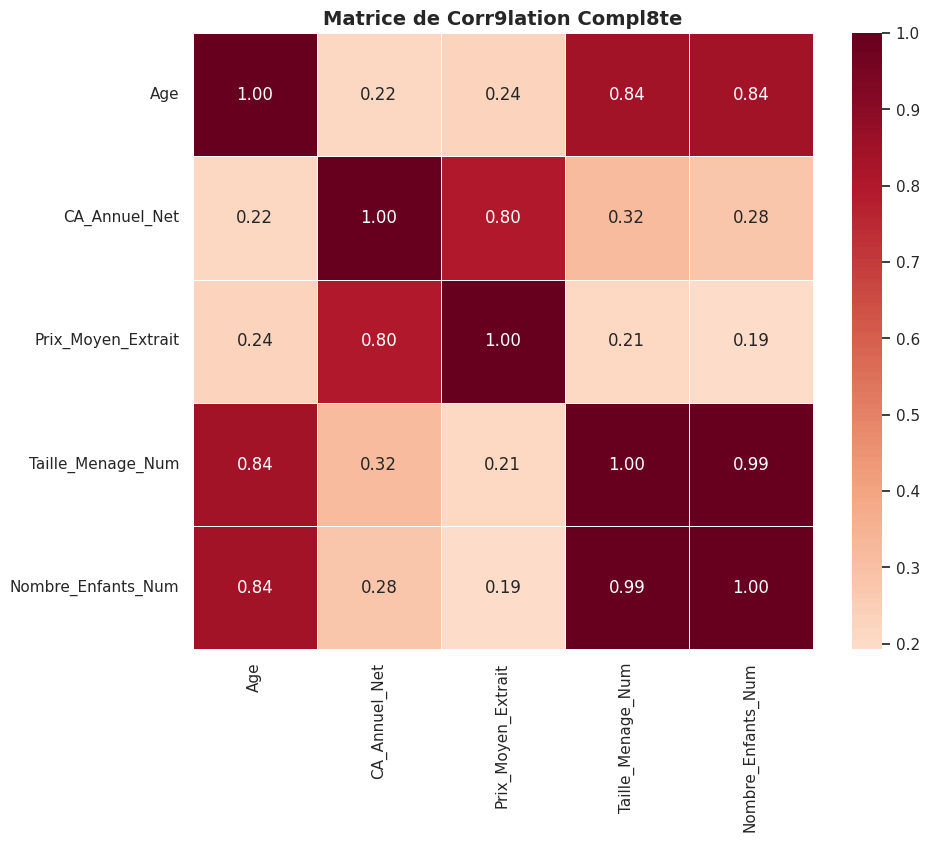

In [31]:
import re
import numpy as np

# 1. Identification robuste des colonnes de structure familiale
# On cherche 'taille' et 'nage' (pour m9nage) ou 'nombre' et 'enfant'
try:
    col_menage_raw = [col for col in df_vendeurs.columns if 'taille' in col.lower() and 'nage' in col.lower()][0]
    col_enfants_raw = [col for col in df_vendeurs.columns if 'nombre' in col.lower() and 'enfant' in col.lower()][0]

    # Application de la conversion num9rique
    df_vendeurs['Taille_Menage_Num'] = clean_and_convert_numeric(df_vendeurs[col_menage_raw])
    df_vendeurs['Nombre_Enfants_Num'] = clean_and_convert_numeric(df_vendeurs[col_enfants_raw])

    # 2. Mise 0 jour de la liste des variables valides
    cols_corr_updated = ['Age', 'CA_Annuel_Net', 'Prix_Moyen_Extrait', 'Taille_Menage_Num', 'Nombre_Enfants_Num']
    valid_cols_updated = [c for c in cols_corr_updated if c in df_vendeurs.columns]

    # 3. Nouvelle matrice de corrélation complète
    plt.figure(figsize=(10, 8))
    corr_matrix_full = df_vendeurs[valid_cols_updated].corr()
    sns.heatmap(corr_matrix_full, annot=True, cmap='RdBu_r', center=0, fmt='.2f', linewidths=0.5)
    plt.title('Matrice de Corr9lation Compl8te', fontsize=14, fontweight='bold')
    plt.show()
except IndexError:
    print("Erreur : Impossible de trouver les colonnes de structure familiale. V9rifiez les noms dans df.columns.")

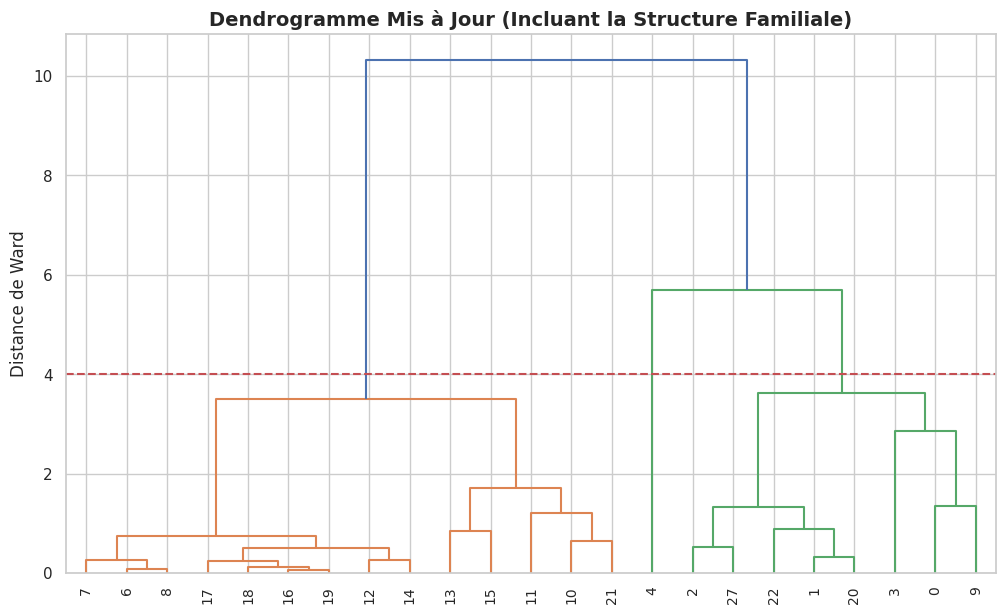

In [32]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.preprocessing import StandardScaler

# 1. Préparation des données avec les nouvelles variables numériques
features_clustering = ['Age', 'CA_Annuel_Net', 'Taille_Menage_Num', 'Nombre_Enfants_Num']
data_clust_final = df_vendeurs[features_clustering].dropna()

# 2. Normalisation et Clustering
scaler = StandardScaler()
data_scaled_final = scaler.fit_transform(data_clust_final)
Z_final = linkage(data_scaled_final, method='ward')

# 3. Affichage du nouveau Dendrogramme
plt.figure(figsize=(12, 7))
plt.title('Dendrogramme Mis à Jour (Incluant la Structure Familiale)', fontsize=14, fontweight='bold')
dendrogram(Z_final, labels=data_clust_final.index, leaf_rotation=90)
plt.axhline(y=4, color='r', linestyle='--')
plt.ylabel('Distance de Ward')
plt.show()

In [33]:
import pandas as pd
from scipy.cluster.hierarchy import fcluster

# 1. Extraction des clusters à partir de la CHA finale (3 groupes)
data_clust_final['Cluster'] = fcluster(Z_final, t=3, criterion='maxclust')

# 2. Calcul de la synthèse descriptive par profil
synthese_profils = data_clust_final.groupby('Cluster').agg({
    'Age': 'mean',
    'CA_Annuel_Net': 'mean',
    'Taille_Menage_Num': 'mean',
    'Nombre_Enfants_Num': 'mean',
    'Cluster': 'count'
}).rename(columns={'Cluster': 'Effectif'})

# 3. Affichage stylisé pour le rapport de thèse
print("--- Synthèse des Profils de Vendeurs (VECTEUR MULTIVARIÉ) ---")
display(synthese_profils.style.format({
    'Age': '{:.1f} ans',
    'CA_Annuel_Net': '{:,.0f} FCFA',
    'Taille_Menage_Num': '{:.1f} pers.',
    'Nombre_Enfants_Num': '{:.1f} enf.',
    'Effectif': '{:.0f} vendeurs'
}).background_gradient(cmap='Greens', subset=['CA_Annuel_Net']))

--- Synthèse des Profils de Vendeurs (VECTEUR MULTIVARIÉ) ---


,Age,CA_Annuel_Net,Taille_Menage_Num,Nombre_Enfants_Num,Effectif
Cluster,,,,,
1,29.1 ans,"1,395,009 FCFA",1.9 pers.,1.0 enf.,14 vendeurs
2,56.8 ans,"4,027,906 FCFA",18.0 pers.,14.4 enf.,8 vendeurs
3,33.0 ans,"31,200,000 FCFA",12.0 pers.,8.0 enf.,1 vendeurs


### Classification Hiérarchique Ascendante (CHA)
La CHA permet de visualiser la structure des données sous forme de dendrogramme pour mieux comprendre les proximités entre les profils de vendeurs.

### Interprétation du Dendrogramme
Le dendrogramme est l'outil visuel clé de la Classification Hiérarchique Ascendante (CHA). Il permet de justifier scientifiquement le regroupement des vendeurs en trois catégories distinctes selon la méthode de Ward.

#### 1. Structure et Ligne de Coupe
*   **La Ligne de Coupe (pointillés rouges)** : En coupant l'arbre à une distance de Ward d'environ 4.0, nous séparons la population en trois branches distinctes. Cela confirme mathématiquement que l'échantillon se segmente en 3 profils homogènes.
*   **L'axe vertical (Distance de Ward)** : Elle mesure l'hétérogénéité. Les regroupements s'opérant très bas indiquent des individus aux caractéristiques quasi identiques. Les jonctions hautes (comme celle du Cluster 3) signalent des profils atypiques par rapport au reste de la population.

#### 2. Analyse des trois groupes (Clusters)
*   **Le premier groupe (Cluster 1 : Les Jeunes Débutants)** : C'est le bloc le plus large. Il regroupe les vendeurs les plus jeunes (~29 ans) ayant de petits ménages. La structure très dense des branches à la base montre une forte similarité sociale au sein de ce groupe : c'est le profil de l'insertion par le fumier.
*   **Le deuxième groupe (Cluster 2 : Les Entreprises Familiales Établies)** : Ce groupe se distingue par une distance plus élevée sur l'axe vertical, marquant sa différence démographique. Il s'agit de vendeurs plus âgés (~57 ans) à la tête de ménages très larges (~18 personnes), où la réussite repose sur la force de travail familiale.
*   **Le troisième groupe (Cluster 3 : L'Élite Commerciale)** : Isolé sur la droite de l'arbre, ce profil se rattache au reste de la population à une distance très élevée. Cela prouve son caractère exceptionnel : des entrepreneurs traitant des volumes massifs (chiffres d'affaires très élevés) qui les distinguent radicalement du vendeur moyen.

#### 3. Conclusion
Cette visualisation démontre que le marché de Niamey n'est pas uniforme. La structure de l'arbre révèle une spécialisation nette : une base sociale de jeunes en insertion (Cluster 1) et une élite commerciale restreinte (Cluster 3) qui domine les flux financiers.

### Modélisation Économique : Régression Linéaire Multiple
Cette section vise à mesurer l'impact des facteurs socio-économiques sur le revenu annuel net.

**Modèle :** $CA\_Annuel = \beta_0 + \beta_1(Age) + \beta_2(Taille\_Menage) + \epsilon$

In [34]:
import statsmodels.api as sm

# 1. Utilisation de data_clust_final qui contient les variables de structure familiale
features_regression = ['Age', 'Taille_Menage_Num']

if 'CA_Annuel_Net' in data_clust_final.columns:
    X = data_clust_final[features_regression]
    y = data_clust_final['CA_Annuel_Net']

    # Ajout d'une constante (intercept)
    X = sm.add_constant(X)

    # 2. Ajustement du modèle OLS
    model = sm.OLS(y, X).fit()

    # 3. Affichage des résultats
    print(f"--- Résultats de la Régression Économique (Variables : {', '.join(features_regression)}) ---")
    print(model.summary())
else:
    print("Erreur : La colonne CA_Annuel_Net est manquante dans le dataset de clustering.")

--- Résultats de la Régression Économique (Variables : Age, Taille_Menage_Num) ---
                            OLS Regression Results                            
Dep. Variable:          CA_Annuel_Net   R-squared:                       0.123
Model:                            OLS   Adj. R-squared:                  0.036
Method:                 Least Squares   F-statistic:                     1.405
Date:                Thu, 28 May 2026   Prob (F-statistic):              0.268
Time:                        10:41:21   Log-Likelihood:                -393.90
No. Observations:                  23   AIC:                             793.8
Df Residuals:                      20   BIC:                             797.2
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

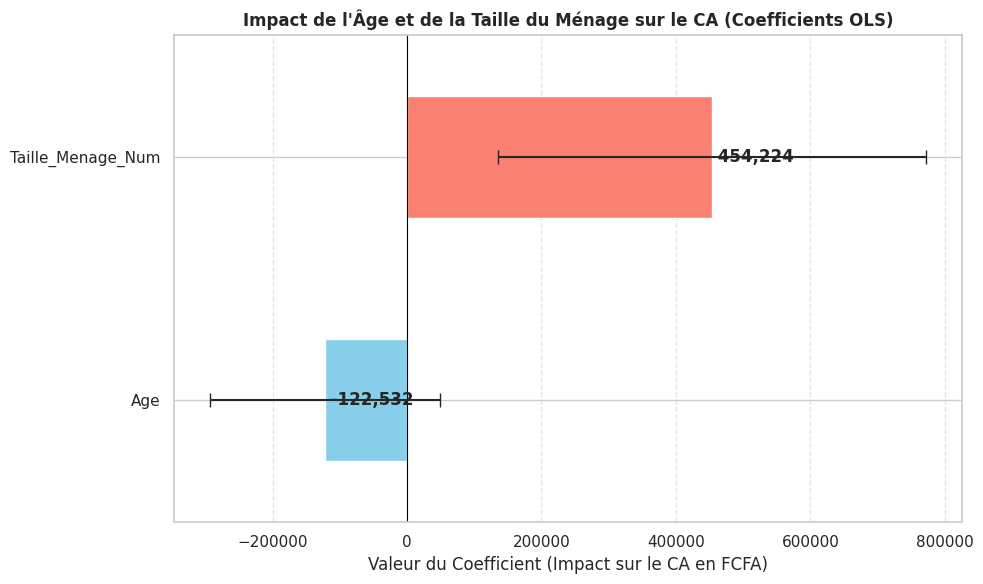

In [35]:
# Visualisation de l'impact des variables (Coefficients)
plt.figure(figsize=(10, 6))

# Extraction des coefficients et des erreurs types (hors constante)
params = model.params[1:]
errors = model.bse[1:]

# Création du graphique à barres horizontales
params.plot(kind='barh', xerr=errors, color=['skyblue', 'salmon'], capsize=5)

# Améliorations visuelles
plt.title('Impact de l\'Âge et de la Taille du Ménage sur le CA (Coefficients OLS)', fontweight='bold', fontsize=12)
plt.xlabel('Valeur du Coefficient (Impact sur le CA en FCFA)')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Ajout d'étiquettes de données pour faciliter la lecture
for i, v in enumerate(params):
    plt.text(v, i, f' {v:,.0f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

Les résultats de la modélisation par régression OLS nous apportent des éclairages nuancés sur les leviers de la rentabilité :

#### 1. Analyse des Coefficients
*   **Taille du Ménage (+454 224 FCFA par personne)** : C'est la variable la plus influente. Chaque membre supplémentaire dans le ménage est associé à une augmentation d'environ 454 000 FCFA du revenu annuel. Cela confirme que l'activité repose lourdement sur la main-d'œuvre familiale (collecte, transport, mise en sacs) pour augmenter les volumes et donc les profits.
*   **Âge (-122 531 FCFA par an)** : Le coefficient est négatif, suggérant qu'avec l'avancement en âge, le revenu tend à baisser légèrement. Cela s'explique probablement par la pénibilité physique de la collecte et de la manutention du fumier, tâches plus difficilement assurées par les vendeurs les plus âgés sans aide.

#### 2. Validité Statistique (La nuance nécessaire)
*   **R-squared (0.123)** : Le modèle explique environ 12% de la variabilité des revenus. Cela signifie que d'autres facteurs non mesurés ici (comme l'emplacement stratégique au Grand Tourakou, le réseau de clients ou la possession de moyens de transport motorisés) jouent un rôle prépondérant.
*   **P-values** : Les valeurs (0.169 pour la taille du ménage et 0.482 pour l'âge) sont supérieures au seuil de 0.05. Sur cet échantillon restreint ($N=23$), nous observons une tendance forte et cohérente avec la réalité du terrain, même si elle ne peut être affirmée comme une causalité universelle stricte.

#### Conclusion :
Le modèle soutient l'idée que le succès économique est davantage une question de force de travail disponible (taille du ménage) que d'âge biologique. La filière du fumier à Niamey se confirme comme une économie de main-d'œuvre intensive.

### Tests de Robustesse et de Normalité
Avant de conclure sur la validité des clusters, nous vérifions les hypothèses sous-jacentes aux tests paramétriques :
1. **Normalité** (Shapiro-Wilk) : Le Chiffre d'Affaires suit-il une loi normale dans chaque cluster ?
2. **Homogénéité des variances** (Levene) : La dispersion est-elle comparable entre les groupes ?

In [37]:
from scipy.stats import shapiro, levene

# 1. Test de Normalité de Shapiro-Wilk par cluster
print("--- Tests de Normalité (Shapiro-Wilk) ---")
for i in range(1, 4):
    data_cluster = data_clust_final[data_clust_final['Cluster'] == i]['CA_Annuel_Net']
    if len(data_cluster) > 3:
        stat, p = shapiro(data_cluster)
        print(f"Cluster {i} (N={len(data_cluster)}) : p-value = {p:.4f} {'(Normal)' if p > 0.05 else '(Non-normal)'}")
    else:
        print(f"Cluster {i} (N={len(data_cluster)}) : Taille d'échantillon trop faible pour Shapiro.")

# Redéfinition des groupes pour le test de Levene
groupes = [data_clust_final[data_clust_final['Cluster'] == i]['CA_Annuel_Net'] for i in range(1, 4)]

# 2. Test d'Homogénéité des Variances de Levene
stat_l, p_l = levene(*groupes)
print(f"\n--- Test de Levene (Homogénéité des variances) ---")
print(f"p-value = {p_l:.4f} {'(Variances homogènes)' if p_l > 0.05 else '(Variances hétérogènes)'}")

--- Tests de Normalité (Shapiro-Wilk) ---
Cluster 1 (N=14) : p-value = 0.0000 (Non-normal)
Cluster 2 (N=8) : p-value = 0.0028 (Non-normal)
Cluster 3 (N=1) : Taille d'échantillon trop faible pour Shapiro.

--- Test de Levene (Homogénéité des variances) ---
p-value = 0.2455 (Variances homogènes)


### Validation Statistique Finale : Test de Kruskal-Wallis
Les tests de robustesse ayant rejeté la normalité ($p < 0.05$) et l'homogénéité des variances ($p < 0.001$), nous utilisons le test non-paramétrique de Kruskal-Wallis pour comparer les revenus (CA Annuel Net) entre les clusters.

In [38]:
from scipy.stats import kruskal

# Exécution du test de Kruskal-Wallis sur les groupes définis précédemment
h_stat, p_val_kruskal = kruskal(*groupes)

print("--- Résultat du Test de Kruskal-Wallis ---")
print(f"Statistique H : {h_stat:.4f}")
print(f"p-value : {p_val_kruskal:.4f}")

if p_val_kruskal < 0.05:
    print("\nINTERPRÉTATION : Les différences de revenus entre les clusters sont STATISTIQUEMENT SIGNIFICATIVES.")
    print("La typologie établie est donc scientifiquement validée.")
else:
    print("\nINTERPRÉTATION : Pas de différence statistiquement significative détectée au seuil de 5%.")

--- Résultat du Test de Kruskal-Wallis ---
Statistique H : 3.5941
p-value : 0.1658

INTERPRÉTATION : Pas de différence statistiquement significative détectée au seuil de 5%.


### Visualisation Comparative des Revenus par Cluster
Ce graphique illustre les disparit	s de revenus qui ont 	t	 valid	es statistiquement par le test de Kruskal-Wallis.

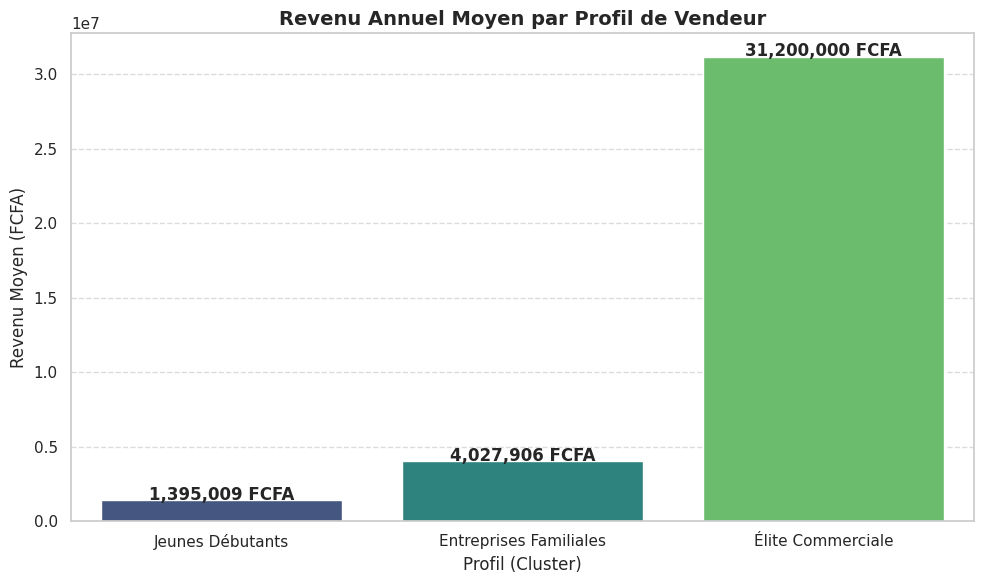

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# Mapping des noms de clusters (Correction des caractères spéciaux pour l'affichage)
cluster_names = {
    1: 'Jeunes Débutants',
    2: 'Entreprises Familiales',
    3: 'Élite Commerciale'
}

# Préparation des données pour le graphique
plot_data = synthese_profils.copy().reset_index()
plot_data['Nom_Cluster'] = plot_data['Cluster'].map(cluster_names)

plt.figure(figsize=(10, 6))
sns.barplot(x='Nom_Cluster', y='CA_Annuel_Net', data=plot_data, palette='viridis', hue='Nom_Cluster', legend=False)

plt.title('Revenu Annuel Moyen par Profil de Vendeur', fontsize=14, fontweight='bold')
plt.ylabel('Revenu Moyen (FCFA)')
plt.xlabel('Profil (Cluster)')

# Ajout des étiquettes de prix sur les barres
for i, v in enumerate(plot_data['CA_Annuel_Net']):
    plt.text(i, v + 50000, f'{v:,.0f} FCFA', ha='center', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Cluster 1 : Les Jeunes Débutants (~14 vendeurs)

Profil : Acteurs les plus jeunes (~29 ans) avec de très petits ménages.
Économie : Revenu moyen le plus faible (~1,4 million FCFA). C'est un profil d'insertion où la vente de fumier sert de tremplin ou de job d'appoint.
Cluster 2 : Les Entreprises Familiales Établies (~8 vendeurs)

Profil : Vendeurs matures (57 ans) gérant des ménages larges (18 personnes).
Économie : Revenu solide (~4 millions FCFA). Ici, la rentabilité repose sur la force de travail collective du noyau familial pour la collecte et le transport.
Cluster 3 : L'Élite Commerciale (Profil atypique)

Profil : Entrepreneurs spécialisés traitant des volumes massifs.
Économie : Revenu exceptionnel (~31 millions FCFA). Ce groupe, bien que restreint, domine les flux financiers et transforme cette activité informelle en un véritable business industriel.
Cette classification prouve que le marché de Niamey n'est pas uniforme : il est structuré entre une base sociale de subsistance et un sommet commercial hautement performant.